# Desafio Meli: Prevenção a fraudes - avaliação do modelo atual e treino de um novo modelo

### Objetivos
1. **Avaliar o modelo atual (champion)** - medir a performance preditiva do modelo em produção a partir dos scores do dataset, justificando quais métricas são mais adequadas para um problema de fraude desbalanceado e por quê. *(Case 1a)*
2. **Treinar um modelo desafiante (Challenger)** capaz de substituir o modelo vigente na discriminação entre transações fraudulentas e legítimas:
    - justificar as técnicas de pré-processamento e o algoritmo escolhidos; *(Case 2a)*
    - comparar os dois modelos no mesmo período de teste (out-of-time), com as mesmas métricas e uma checagem de consistência dia a dia. *(Case 2b)*
3. **Definir o ponto de corte que maximiza o lucro** - considerando comissão de 10% sobre cada transação legítima aprovada e perda de 100% do valor de cada fraude aprovada. *(Case 2c)*

A ideia inicial é utilizar um algoritmo de Boost (LightGBM) para o challenger, visto que este se adequa a features categóricas

### Premissas
- `monto` está em uma única moeda para todos os países (as medianas por país são parecidas).
- A amostra tem exatamente 5% de fraude, o que indica que foi estratificada. O ponto de corte encontrado vale para essa taxa e precisa ser revisto com a taxa real de produção.
- Não existe identificador de usuário, cartão ou dispositivo, então não dá para criar features de histórico por cliente.
- As fraudes mais recentes podem ainda não ter sido confirmadas quando os dados foram extraídos (maturidade do rótulo).

### Estrutura do notebook
1. Dados e análise exploratória (EDA)
2. Objetivo 1: avaliação do modelo atual (champion)
3. Objetivo 2a: split out-of-time
4. Objetivo 2a: features
5. Objetivo 2a: modelos
6. Objetivo 2c: ponto de corte
7. Objetivo 2b: comparação no teste
8. Conclusão, limitações e uso de IA

## Imports e configuração

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from scipy.stats import ks_2samp
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve, precision_recall_curve

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
LEGIT_COLOR, FRAUD_COLOR = "#2a78d6", "#eb6834"

## Dados e análise exploratória (EDA)

In [2]:
# Attention! Please use this cell to load the dataset that will be needed in this case.

df = pd.read_csv('https://hr-projects-assets-prod.s3.amazonaws.com/3st1g8gm56o/ed953178414189325c980dc1a9214b97/data.csv')

In [3]:
# Cópia dos dados originais, usada mais adiante na preparação da base dos modelos
df_bruto = df.copy()
df["fecha"] = pd.to_datetime(df["fecha"])

In [4]:
df.head()

,a,b,c,d,e,f,g,h,i,j,k,l,m,n,o,p,fecha,monto,score,fraude
0,4,0.7685,94436.24,20.0,0.444828,1.0,BR,5,Máquininha Corta Barba Cabelo Peito Perna Pelo...,cat_8d714cd,0.883598,240.0,102.0,1,NaN,N,2020-03-27 11:51:16,5.64,66,0
1,4,0.7550,9258.50,1.0,0.000000,33.0,BR,0,Avental Descartavel Manga Longa - 50 Un. Tnt ...,cat_64b574b,0.376019,4008.0,0.0,1,Y,N,2020-04-15 19:58:08,124.71,72,0
2,4,0.7455,242549.09,3.0,0.000000,19.0,AR,23,Bicicleta Mountain Fire Bird Rodado 29 Alumini...,cat_e9110c5,0.516368,1779.0,77.0,1,NaN,N,2020-03-25 18:13:38,339.32,95,0
3,4,0.7631,18923.90,50.0,0.482385,18.0,BR,23,Caneta Delineador Carimbo Olho Gatinho Longo 2...,cat_d06e653,0.154036,1704.0,1147.0,1,NaN,Y,2020-04-16 16:03:10,3.54,2,0
4,2,0.7315,5728.68,15.0,0.000000,1.0,BR,2,Resident Evil Operation Raccoon City Ps3,cat_6c4cfdc,0.855798,1025.0,150.0,1,NaN,N,2020-04-02 10:24:45,3.53,76,0


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 20 columns):
 #   Column  Non-Null Count   Dtype         
---  ------  --------------   -----         
 0   a       150000 non-null  int64         
 1   b       137016 non-null  float64       
 2   c       137016 non-null  float64       
 3   d       149635 non-null  float64       
 4   e       150000 non-null  float64       
 5   f       149989 non-null  float64       
 6   g       149806 non-null  str           
 7   h       150000 non-null  int64         
 8   i       150000 non-null  str           
 9   j       150000 non-null  str           
 10  k       150000 non-null  float64       
 11  l       149989 non-null  float64       
 12  m       149635 non-null  float64       
 13  n       150000 non-null  int64         
 14  o       41143 non-null   str           
 15  p       150000 non-null  str           
 16  fecha   150000 non-null  datetime64[us]
 17  monto   150000 non-null  float64       


### Distribuição do target

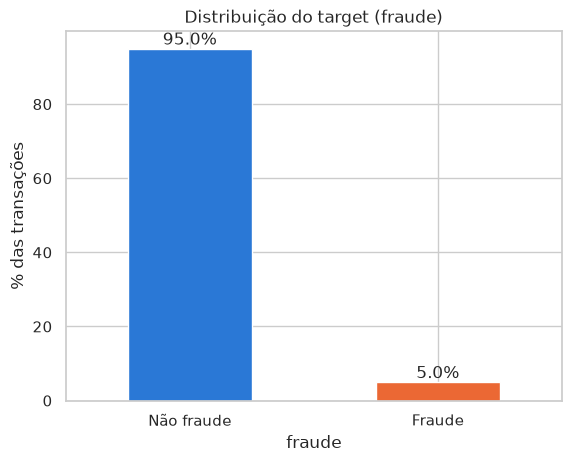

In [6]:
proportions = df["fraude"].value_counts(normalize=True) * 100
ax = proportions.plot(kind="bar", color=[LEGIT_COLOR, FRAUD_COLOR])
ax.bar_label(ax.containers[0], fmt="%.1f%%")
ax.set_xticklabels(["Não fraude", "Fraude"], rotation=0)
ax.set(ylabel="% das transações", title="Distribuição do target (fraude)")
plt.show()

### Validação de nulos

In [7]:
df.isnull().sum()

a              0
b          12984
c          12984
d            365
e              0
f             11
g            194
h              0
i              0
j              0
k              0
l             11
m            365
n              0
o         108857
p              0
fecha          0
monto          0
score          0
fraude         0
dtype: int64

*Análise de nulos em função do tempo (por dia)*

Observação: Há uma grande quantidade de nulos para b e c em alguns dias de março (gráfico abaixo), isso acende um alerta já que o volume de nulos em ambas as features é o mesmo o que pode indicar problemas nos dados que serão alimentados ao modelo

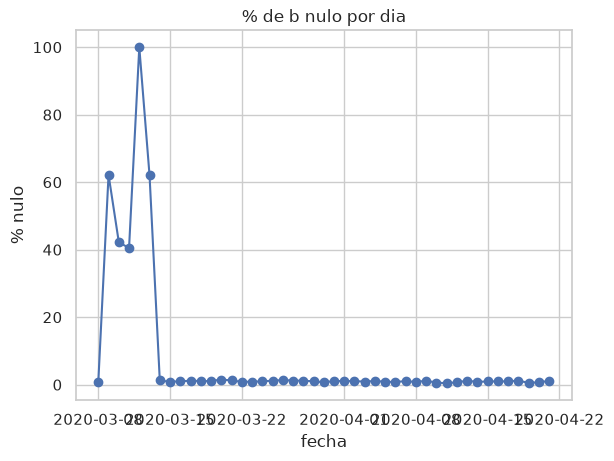

,transacoes,pct_b_nulo,pct_c_nulo
fecha,,,
2020-03-08,2838,0.8,0.8
2020-03-09,4173,62.2,62.2
2020-03-10,4105,42.3,42.3
2020-03-11,3899,40.4,40.4
2020-03-12,3787,100.0,100.0
2020-03-13,3229,62.0,62.0
2020-03-14,2560,1.2,1.2
2020-03-15,2770,0.9,0.9
2020-03-16,4202,1.0,1.0


In [8]:
nulos_dia = df.groupby(df["fecha"].dt.date).agg(
    transacoes=("b", "size"),
    pct_b_nulo=("b", lambda s: s.isnull().mean() * 100),
    pct_c_nulo=("c", lambda s: s.isnull().mean() * 100),
)

ax = nulos_dia["pct_b_nulo"].plot(marker="o", title="% de b nulo por dia")
ax.set_ylabel("% nulo")
plt.show()

nulos_dia.round(1).head(14)

Analisando o gráfico e a tabela vemos que esse problema ocorre nos dias 09 a 13, com um grande agravante no dia 12. Isso indica que algo pode ter ocorrido nessa semana que pode ter afetado os dados para essas features em específico. Após esse período o valor cai para menos de 1%

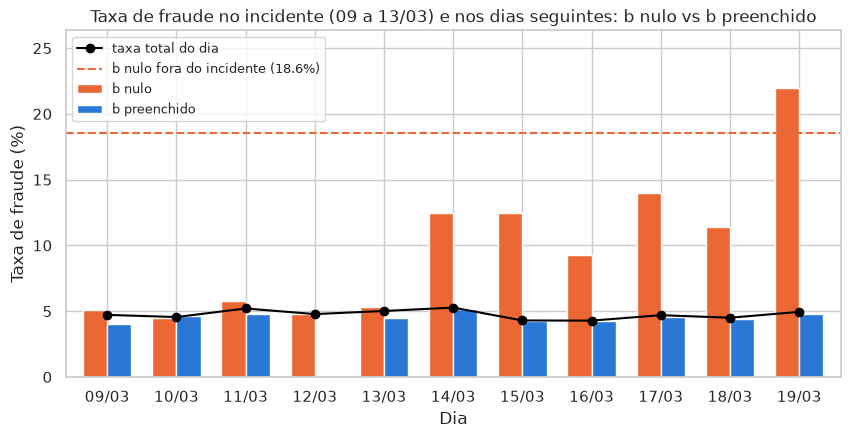

taxa de fraude (%)                           transações  \
b                      b nulo b preenchido total do dia     b nulo   
fecha                                                                
2020-03-09                5.1          4.1          4.7     2595.0   
2020-03-10                4.5          4.6          4.6     1735.0   
2020-03-11                5.8          4.8          5.2     1577.0   
2020-03-12                4.8          NaN          4.8     3787.0   
2020-03-13                5.3          4.5          5.0     2003.0   
2020-03-14               12.5          5.2          5.3       32.0   
2020-03-15               12.5          4.2          4.3       24.0   
2020-03-16                9.3          4.2          4.3       43.0   
2020-03-17               14.0          4.6          4.7       50.0   
2020-03-18               11.4          4.4          4.5       44.0   
2020-03-19               22.0          4.8          4.9       41.0   

                         
b          b preenchido  
fecha                    
2020-03-09       1578.0  
2020-03-10       2370.0  
2020-03-11       2322.0  
2020-03-12          NaN  
2020-03-13       1226.0  
2020-03-14       2528.0  
2020-03-15       2746.0  
2020-03-16       4159.0  
2020-03-17       4230.0  
2020-03-18       3997.0  
2020-03-19       3858.0

In [9]:
# Incidente de coleta (09/03 a 13/03), encontrado no gráfico diário de nulos, e os dias seguintes para comparação
incidente = df["fecha"].between("2020-03-09", "2020-03-14", inclusive="left")
dias = df[df["fecha"].between("2020-03-09", "2020-03-20", inclusive="left")]

b_status = dias["b"].isnull().map({True: "b nulo", False: "b preenchido"})
taxa_dia = dias.groupby([dias["fecha"].dt.date, b_status])["fraude"].mean().unstack() * 100
taxa_dia["total do dia"] = dias.groupby(dias["fecha"].dt.date)["fraude"].mean() * 100
volume_dia = dias.groupby([dias["fecha"].dt.date, b_status]).size().unstack()

# Referência: taxa de fraude de b nulo nos dias normais
fora = df[~incidente]
taxa_nulo_fora = fora.loc[fora["b"].isnull(), "fraude"].mean() * 100

ax = taxa_dia[["b nulo", "b preenchido"]].plot(kind="bar", color=[FRAUD_COLOR, LEGIT_COLOR], width=0.7, figsize=(10, 4.5))
ax.plot(range(len(taxa_dia)), taxa_dia["total do dia"], color="black", marker="o", label="taxa total do dia")
ax.axhline(taxa_nulo_fora, color=FRAUD_COLOR, linestyle="--", label=f"b nulo fora do incidente ({taxa_nulo_fora:.1f}%)")
ax.set(title="Taxa de fraude no incidente (09 a 13/03) e nos dias seguintes: b nulo vs b preenchido", xlabel="Dia", ylabel="Taxa de fraude (%)",
       ylim=(0, max(taxa_nulo_fora, taxa_dia.max().max()) * 1.2))
ax.legend(fontsize=9, loc="upper left")
ax.set_xticklabels([d.strftime("%d/%m") for d in taxa_dia.index], rotation=0)
plt.show()

pd.concat([taxa_dia.round(1), volume_dia], axis=1, keys=["taxa de fraude (%)", "transações"])

Nos dias do incidente (09 a 13/03), a taxa de fraude com `b` nulo (de 4,5% a 5,8%) fica no mesmo nível da taxa com `b` preenchido (de 4,1% a 4,8%) e da taxa total de cada dia (de 4,6% a 5,2%). Em 12/03 todas as transações tiveram `b` nulo, por isso não há barra azul nesse dia. Nesses dias o nulo foi causado pela falha de coleta e não diz nada sobre fraude.

Nos dias seguintes (14 a 19/03) o volume de `b` nulo volta ao normal, cerca de 40 transações por dia, e a taxa de fraude delas sobe para 9% a 22% (13,7% no período), contra 4,5% com `b` preenchido. Fora do incidente, portanto, o nulo de `b` ainda indica mais risco, mas atinge um grupo muito pequeno (cerca de 1% das transações).

**Decisão:** `b` segue no modelo com os nulos, que o LightGBM trata nativamente. Não criamos uma flag separada para o nulo de `b` pois o grupo é pequeno (cerca de 1% das transações fora do incidente), e num teste a flag respondeu por menos de 1% da importância do modelo. Ela adicionaria uma regra de datas para manter (excluir a janela do incidente) com ganho mínimo.

#### Nulos: taxa de fraude quando o valor é nulo vs não nulo
Em covenções a ideia de drop de nulo com taxa de até 3% é aceita ou imput de dados para evitar a perda de informação relevante em outras features. Porém para problemas complexos (como fraude) é necessário ir além disso, a quantidade de nulos sozinha não decide a remoção, pois o que verdadeiramente importa é se o nulo diz algo sobre fraude. Se a taxa muda muito entre nulo e preenchido, o nulo é informativo e vira sinal, em vez de ser imputado ou descartado.

In [10]:
null_cols = df.columns[df.isnull().any()]

null_table = pd.DataFrame({
    "% nulos": df[null_cols].isnull().mean() * 100,
    "fraude se nulo": {c: df.loc[df[c].isnull(), "fraude"].mean() * 100 for c in null_cols},
    "fraude não nulo": {c: df.loc[df[c].notnull(), "fraude"].mean() * 100 for c in null_cols},
})

null_table.sort_values("% nulos", ascending=False).round(2)

,% nulos,fraude se nulo,fraude não nulo
o,72.57,2.05,12.79
b,8.66,6.38,4.87
c,8.66,6.38,4.87
d,0.24,7.95,4.99
m,0.24,7.95,4.99
g,0.13,7.73,5.00
f,0.01,0.00,5.00
l,0.01,0.00,5.00


#### Análise da feature 'o' (maior índice de nulos)

In [11]:
nulos_o = df["o"].fillna("nulo")

tabela_o = df.groupby(nulos_o)["fraude"].agg(transacoes="size", fraudes="sum")
tabela_o["taxa_fraude_%"] = tabela_o["fraudes"] / tabela_o["transacoes"] * 100
tabela_o["%_transacoes"] = tabela_o["transacoes"] / tabela_o["transacoes"].sum() * 100
tabela_o["%_fraudes"] = tabela_o["fraudes"] / tabela_o["fraudes"].sum() * 100
tabela_o.round(1)

,transacoes,fraudes,taxa_fraude_%,%_transacoes,%_fraudes
o,,,,,
N,17052,3709,21.8,11.4,49.5
Y,24091,1554,6.5,16.1,20.7
nulo,108857,2237,2.1,72.6,29.8


In [12]:
# KS da variável o: cada nível é trocado pela sua taxa de fraude (nulo = categoria própria)
o_risco = nulos_o.map(df.groupby(nulos_o)["fraude"].mean())
ks_o = ks_2samp(o_risco[df["fraude"] == 1], o_risco[df["fraude"] == 0]).statistic
print(f"KS da variável o: {ks_o:.3f}")

KS da variável o: 0.450


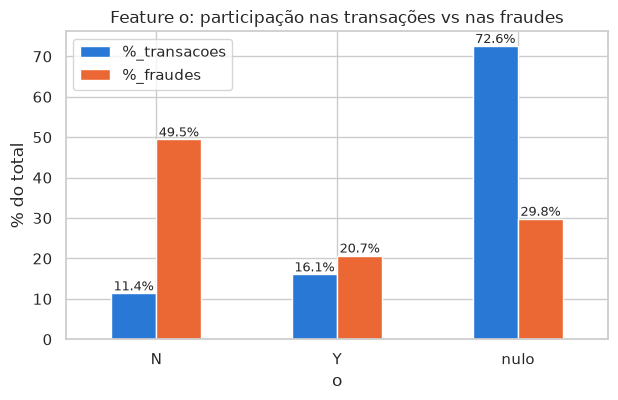

In [13]:
ax = tabela_o[["%_transacoes", "%_fraudes"]].plot(kind="bar", color=[LEGIT_COLOR, FRAUD_COLOR], figsize=(7, 4))
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", fontsize=9)
ax.set(title="Feature o: participação nas transações vs nas fraudes", xlabel="o", ylabel="% do total")
plt.xticks(rotation=0)
plt.show()


In [14]:
nulos_imputados = df["o"].fillna(df["o"].mode()[0])  # valor mais comum entre os preenchidos: "Y"

comparacao = pd.concat({
    "% fraude mantendo nulo": df.groupby(nulos_o)["fraude"].mean() * 100,
    "% fraude nulo imputado com 'Y'": df.groupby(nulos_imputados)["fraude"].mean() * 100,
}, axis=1)
comparacao.round(1)

,% fraude mantendo nulo,% fraude nulo imputado com 'Y'
o,,
N,21.8,21.8
Y,6.5,2.9
nulo,2.1,NaN


Caso optasse por imputar o valor, a taxa de fraude relacionada a Y cairia para 2,9%, assim perdemos boa parte da explicabilidade da categoria. Assim mantém-se esta categoria para o treinamento do modelo, porém, serão feitos dois testes com e sem a presença dela para verificar sua importância ao modelo.

### Análise do target (fraude)

#### Distribuição de fraude por semana

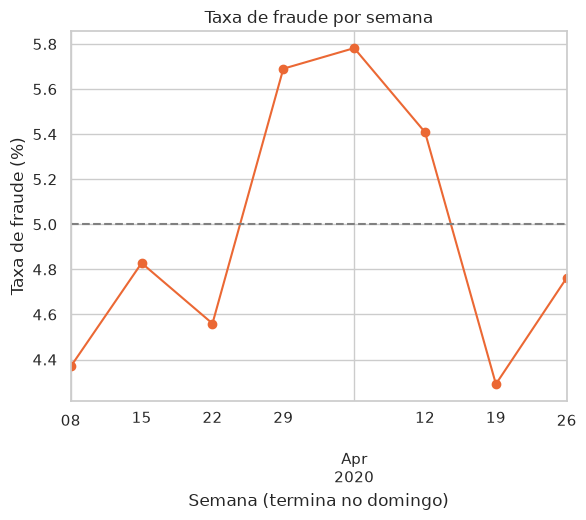

,transacoes,taxa_fraude
fecha,,
2020-03-08,2838,4.37
2020-03-15,24523,4.83
2020-03-22,25199,4.56
2020-03-29,20069,5.69
2020-04-05,17434,5.78
2020-04-12,24443,5.41
2020-04-19,25332,4.29
2020-04-26,10162,4.76


In [15]:
weekly = df.groupby(pd.Grouper(key="fecha", freq="W-SUN")).agg(
    transacoes=("fraude", "size"),
    taxa_fraude=("fraude", "mean"),
)
weekly["taxa_fraude"] *= 100

ax = weekly["taxa_fraude"].plot(marker="o", color=FRAUD_COLOR)
ax.axhline(df["fraude"].mean() * 100, color="gray", linestyle="--")  # média geral (5%)
ax.set(title="Taxa de fraude por semana", xlabel="Semana (termina no domingo)", ylabel="Taxa de fraude (%)")
plt.show()

weekly.round(2)

A taxa de fraude semanal varia entre ~4,4% e ~5,8%. O pico fica no fim de março e início de abril, e as semanas mais recentes (período de teste) têm a menor taxa. Parte dessa queda pode ser maturidade da target em que fraudes recentes podem ainda não ter sido confirmadas quando os dados foram extraídos.

#### Distribuição de valor: fraude vs não fraude observando o valor da transação (monto)

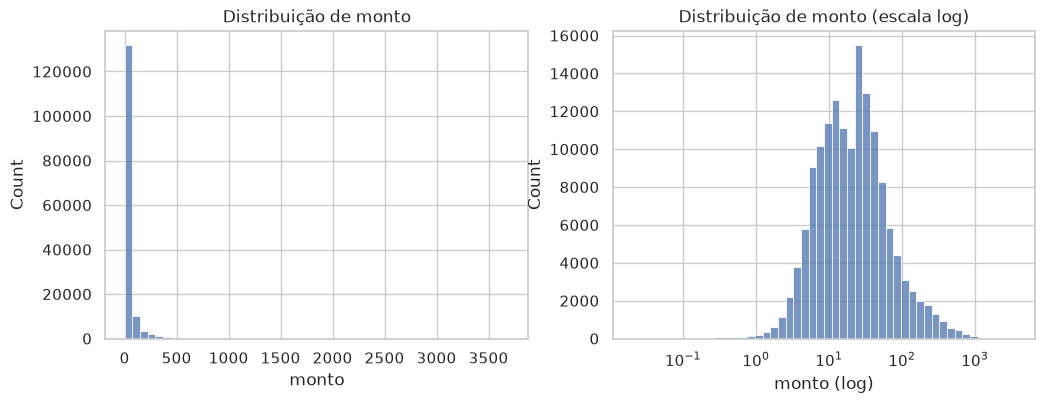

count    150000.00
mean         43.52
std          91.56
min           0.02
25%           9.38
50%          20.61
75%          40.69
max        3696.35
Name: monto, dtype: float64

In [16]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df["monto"], bins=50, ax=ax1)
ax1.set(title="Distribuição de monto", xlabel="monto")

sns.histplot(df["monto"], bins=50, log_scale=True, ax=ax2)
ax2.set(title="Distribuição de monto (escala log)", xlabel="monto (log)")

plt.show()

df["monto"].describe().round(2)

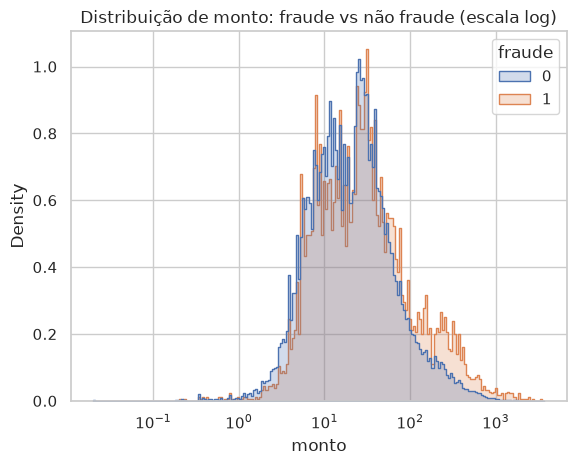

,count,mean,std,min,50%,95%,99%,max
fraude,,,,,,,,
0,142500.0,41.97,85.71,0.02,20.18,151.10,397.66,3696.35
1,7500.0,72.97,164.84,0.21,25.87,313.66,736.72,3424.81


In [17]:
sns.histplot(data=df, x="monto", hue="fraude", log_scale=True,
             stat="density", common_norm=False, element="step")
plt.title("Distribuição de monto: fraude vs não fraude (escala log)")
plt.show()

df.groupby("fraude")["monto"].describe(percentiles=[0.5, 0.95, 0.99]).round(2)

`monto` é muito assimétrico (média de ~43, mediana de ~20 e máximo ~3.700), então usou-se escala log. Pode-se ver que tem-se uma cauda longa em que majoritariamente os valores de transação estão concentrados à esquerda do histograma de distribuição em escala comum. 

No eixo log, cada marca multiplica o valor por 10. A maior parte das transações fica entre 10 e 40 (mediana ≈ 20). As duas classes se sobrepõem nessa faixa, mas acima de ~100 a curva de fraude fica acima da de não fraude: as fraudes se concentram nos valores altos, o que explica elas serem 5% das transações e 8,4% do valor total.

#### Taxa de fraude por hora do dia

A hipótese adotada é que as fraudes possam estar concentradas em transações que ocorrem fora do horário comercial. Esse é um comportamento que pode ser esperado devido ao ritmo desacelerado da madrugada em que a vitima está ausente do celular/computador, há menos monitoramento ativo e revisão manual.

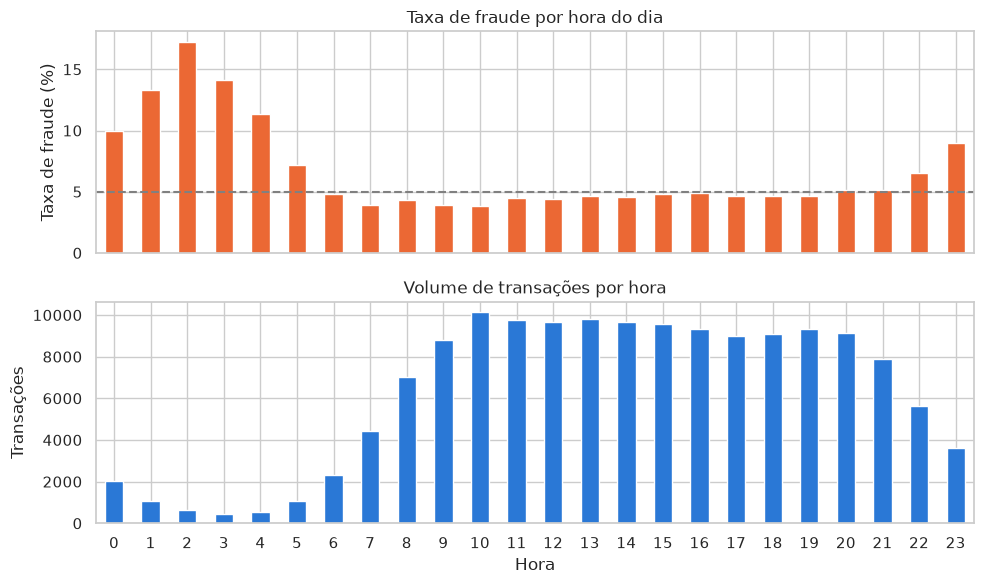

In [18]:
df["hora"] = df["fecha"].dt.hour
by_hour = df.groupby("hora")["fraude"].agg(taxa="mean", transacoes="size")
by_hour["taxa"] *= 100

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
by_hour["taxa"].plot(kind="bar", color=FRAUD_COLOR, ax=ax1)
ax1.axhline(5, color="gray", linestyle="--")  # média geral
ax1.set(title="Taxa de fraude por hora do dia", ylabel="Taxa de fraude (%)")

by_hour["transacoes"].plot(kind="bar", color=LEGIT_COLOR, ax=ax2)
ax2.set(title="Volume de transações por hora", xlabel="Hora", ylabel="Transações")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [19]:
df["periodo"] = pd.cut(df["hora"], bins=[-1, 5, 11, 17, 23],
                       labels=["madrugada (0-5h)", "manhã (6-11h)", "tarde (12-17h)", "noite (18-23h)"])

periodo = df.groupby("periodo", observed=True)["fraude"].agg(taxa="mean", transacoes="size", fraudes="sum")
periodo["taxa"] *= 100
periodo["% transações"] = periodo["transacoes"] / len(df) * 100
periodo["% fraudes"] = periodo["fraudes"] / df["fraude"].sum() * 100
periodo.round(1)

,taxa,transacoes,fraudes,% transações,% fraudes
periodo,,,,,
madrugada (0-5h),11.3,5814,657,3.9,8.8
manhã (6-11h),4.1,42455,1759,28.3,23.5
tarde (12-17h),4.7,57055,2664,38.0,35.5
noite (18-23h),5.4,44676,2420,29.8,32.3


Conclusões
- No período das 22h até as 6h o número de transações diminui, porém a taxa de fraudes de acordo com o volume de transações mais que dobra para os mesmos horários.
- A madrugada (0–5h) tem 11,3% de fraude, mais que o dobro da média. Tem apenas 3,9% das transações, mas compõe 8,8% das fraudes com pico às 2h (17,2%).
- O padrão aparece em BR e em AR, então não é efeito do mix de países.
- O valor mediano total transacionado das transações da madrugada não é maior que no resto do dia: é o horário em si que apresenta uma taxa de fraudes maior.
- Ideia para o feature engineering: Usar a hora do dia como feature (seção 4), dado que o padrão de fraude se apresenta mais promissor na madrugada

#### Participação da fraude: por quantidade vs por valor de transação (`monto`)

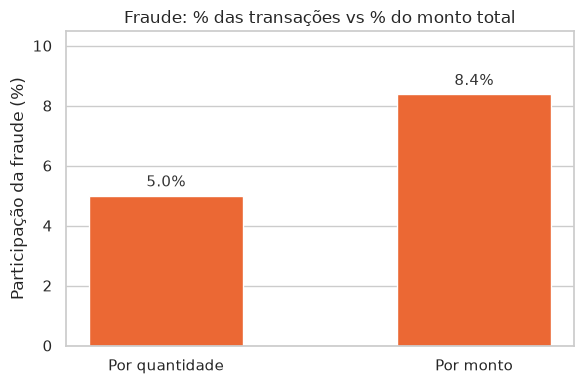

Por quantidade    5.00
Por monto         8.38
dtype: float64

In [20]:
is_fraud = df["fraude"] == 1
fraud_share = pd.Series({
    "Por quantidade": is_fraud.mean(),
    "Por monto": df.loc[is_fraud, "monto"].sum() / df["monto"].sum(),
}) * 100

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(fraud_share.index, fraud_share.values, color=FRAUD_COLOR, width=0.5)
ax.bar_label(bars, labels=[f"{v:.1f}%" for v in fraud_share], padding=4, fontsize=11, color="#333333")
ax.set(ylabel="Participação da fraude (%)", ylim=(0, fraud_share.max() * 1.25),
       title="Fraude: % das transações vs % do monto total")
ax.grid(axis="x", visible=False)
plt.tight_layout()
plt.show()

fraud_share.round(2)

As fraudes ocupam apenas 5% das transações, contudo tem um grande peso no valor total transacionado visto que apresentam maior concentração em valores mais altos. Dado que o valor transacionado que define o lucro e não a quantidade (uma fraude de $1000,00 pesa mais que 10 fraudes de $10,00), isso impacta diretamente o lucro esperado e a política de corte a ser adotada.

### Taxa de fraude das variáveis numéricas
Dividiu-se cada variável em decis e calculou-se a fraude para cada grupo, tornando possível observar o comportamento de fraude em cada faixa.
- Linha plana perto da média (5%) = sem sinal.
- Linha subindo ou descendo = a variável separa fraude de não fraude.

O título traz o KS da variável sozinha (0 = sem separação; acima de ~0,8 seria suspeita de vazamento). Linhas com nulo ficam de fora; o nulo foi analisado na tabela de nulos.

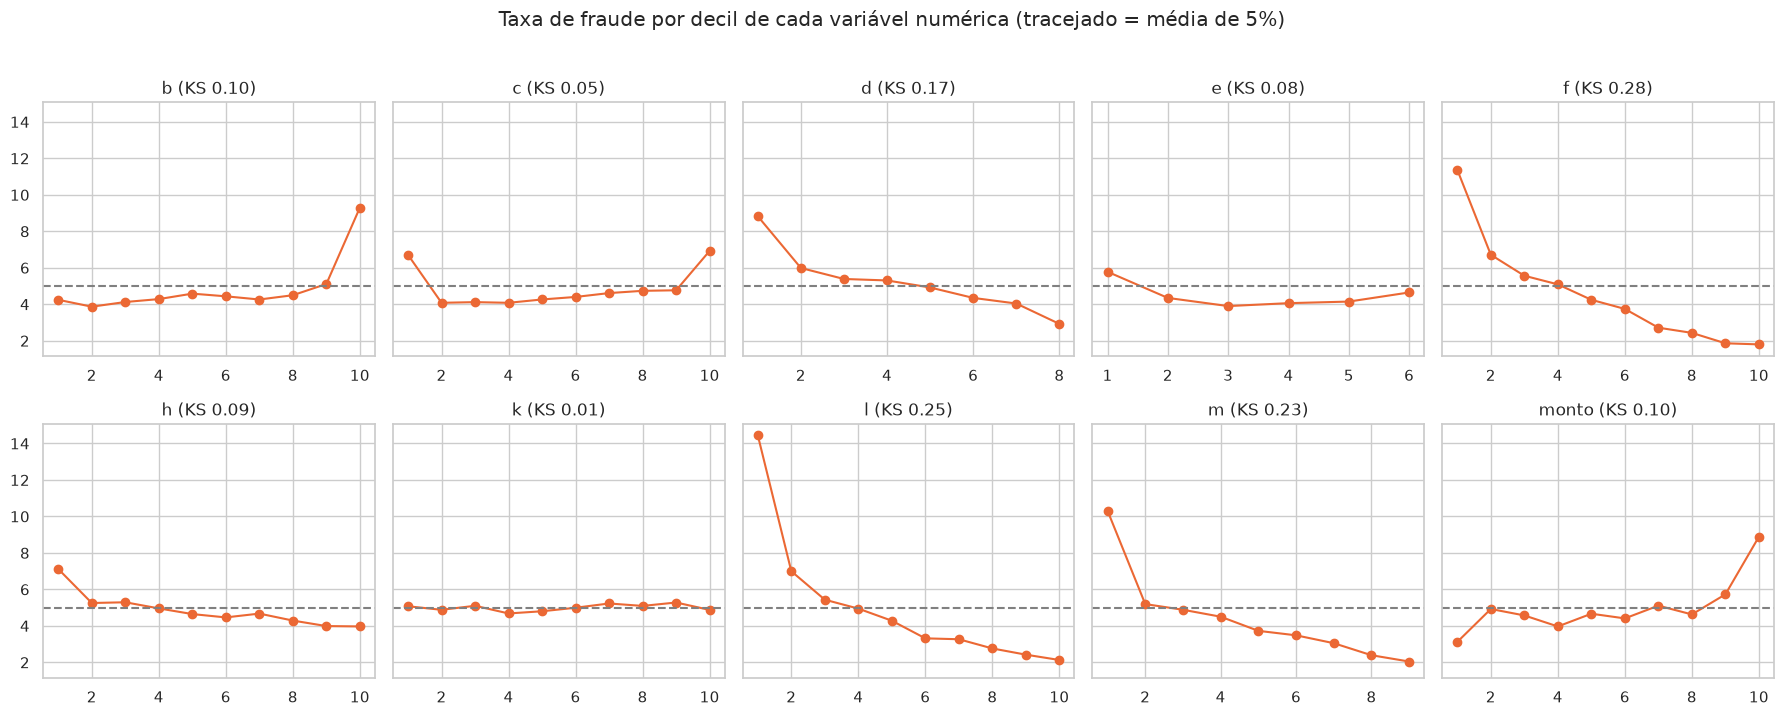

In [21]:
numeric_cols = ["b", "c", "d", "e", "f", "h", "k", "l", "m", "monto"]
fig, axes = plt.subplots(2, 5, figsize=(18, 7), sharey=True)

for ax, col in zip(axes.flatten(), numeric_cols):
    data = df[[col, "fraude"]].dropna()

    # Taxa de fraude em cada decil da variável
    rate = data.groupby(pd.qcut(data[col], 10, duplicates="drop"), observed=True)["fraude"].mean() * 100
    ks = ks_2samp(data.loc[data["fraude"] == 1, col], data.loc[data["fraude"] == 0, col]).statistic

    ax.plot(range(1, len(rate) + 1), rate.values, marker="o", color=FRAUD_COLOR)
    ax.axhline(5, color="gray", linestyle="--")  # média geral
    ax.set_title(f"{col} (KS {ks:.2f})")

fig.suptitle("Taxa de fraude por decil de cada variável numérica (tracejado = média de 5%)", y=1.02)
plt.tight_layout()
plt.show()

 - *f, l, m* apresentam uma separação mais forte (KS 0,25–0,28): a fraude se concentra nos menores valores. *d* tem uma separação moderada (0,17) e *h*  acaba sendo fraca (0,09), com a mesma tendência.
 - *b* e monto têm KS baixo (~0,10), mas o sinal está concentrado no topo: nos maiores valores a taxa de fraude sobe para ~9%. O KS é baixo porque só ~10–20% das linhas diferem.
 - *c* tem KS baixo (0,05), com forma de U: as duas pontas têm mais fraude = indicada para ser, pois possui o mesmo comportamento que em b.
 - *e* é fraca (KS 0,08), sem padrão claro entre os decis = indicada para ser removida.
 - *k*  não tem sinal (taxa plana, KS 0,01) = indicada para ser removida.
 - Nenhuma variável passa de KS 0,8, então não há sinal de leakage.
 - Essas leituras são de cada variável sozinha; a importância no modelo será confirmada na seção de modelos (importância das features).

### Taxa de fraude das variáveis categóricas
Para cada nível da variável, a taxa de fraude, com o número de transações impresso na tabela acima de cada gráfico: uma taxa alta com poucas transações não é confiável.
- Nulo vira um nível próprio (`nulo`), porque ele pode ser informativo (caso de `o`).
- Países: mantemos BR, AR, UY e US, que somam ~99% das transações; os demais países e os nulos de `g` vão para `OUTROS`.
- `j` (8.324 categorias) fica de fora: tem níveis demais para um gráfico e será tratada no feature engineering.

#### Análise por país de origem das transações

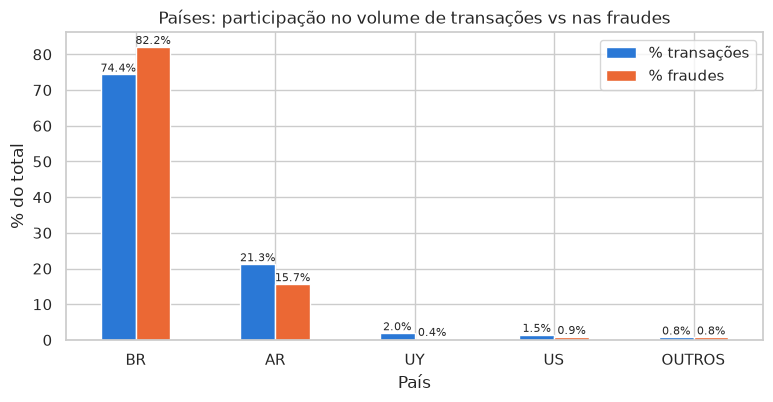

,transacoes,fraudes,% transações,% fraudes
pais,,,,
BR,111628,6162,74.4,82.2
AR,31964,1179,21.3,15.7
UY,2967,29,2.0,0.4
US,2273,70,1.5,0.9
OUTROS,1168,60,0.8,0.8


In [22]:
PAISES_PRINCIPAIS = ["BR", "AR", "UY", "US"]

# Países principais + OUTROS (inclui os demais países e os nulos de g)
df["pais"] = df["g"].where(df["g"].isin(PAISES_PRINCIPAIS), "OUTROS")

paises = df.groupby("pais").agg(transacoes=("fraude", "size"), fraudes=("fraude", "sum"))
paises["% transações"] = paises["transacoes"] / paises["transacoes"].sum() * 100
paises["% fraudes"] = paises["fraudes"] / paises["fraudes"].sum() * 100
paises = paises.sort_values("transacoes", ascending=False)

ax = paises[["% transações", "% fraudes"]].plot(kind="bar", color=[LEGIT_COLOR, FRAUD_COLOR], figsize=(9, 4))
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", fontsize=8)
ax.set(title="Países: participação no volume de transações vs nas fraudes", xlabel="País", ylabel="% do total")
plt.xticks(rotation=0)
plt.show()

paises.round(1)

BR concentra 74% das transações, mas 82% das fraudes: proporcionalmente, mais fraude que os outros países. AR tem menos fraude do que o seu volume (21% das transações, 16% das fraudes), e UY tem bem menos (2% vs 0,4%). Juntos, BR e AR respondem por ~98% das fraudes, mas os demais países continuam no modelo, agrupados em OUTROS, porque o modelo vai pontuar transações de todos eles.

#### Distribuição de fraude nas demais categóricas

   mean    size
a              
1  9.42    4195
2  7.78   14378
3  9.06    2848
4  4.46  128579


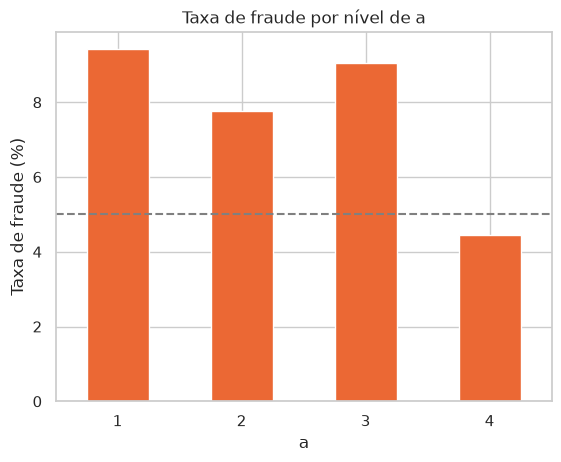

    mean    size
n               
0  16.11   14647
1   3.80  135353


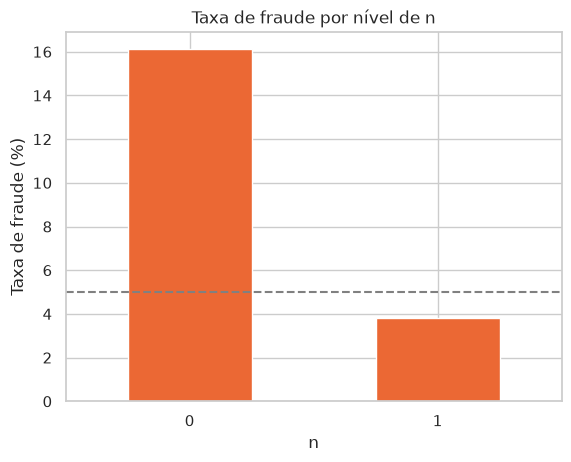

       mean    size
o                  
N     21.75   17052
Y      6.45   24091
nulo   2.05  108857


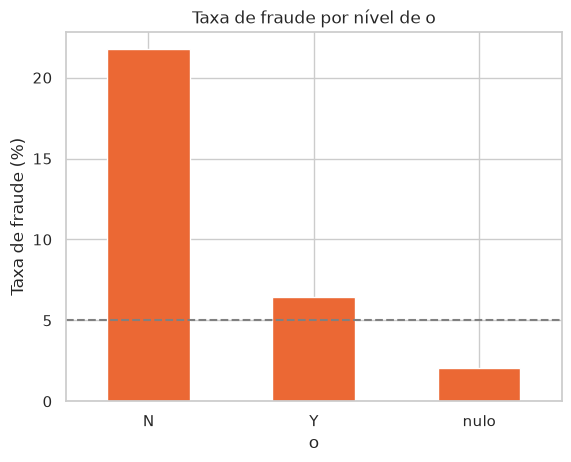

   mean   size
p             
N  7.60  66871
Y  2.91  83129


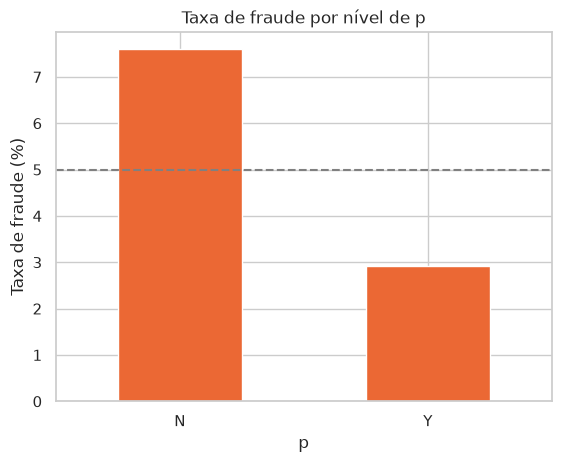

In [23]:
for col in ["a", "n", "o", "p"]:
    levels = df[col].fillna("nulo").astype(str)

    table = df.groupby(levels)["fraude"].agg(["mean", "size"])
    table["mean"] *= 100
    print(table.round(2))

    ax = table["mean"].plot(kind="bar", color=FRAUD_COLOR)
    ax.axhline(5, color="gray", linestyle="--")  # média geral
    ax.set(title=f"Taxa de fraude por nível de {col}", xlabel=col, ylabel="Taxa de fraude (%)")
    plt.xticks(rotation=0)
    plt.show()

### Resumo por coluna
Uma linha por coluna: tipo, decisão (com o tratamento de nulos quando houver) e % de nulos.
Regra: manter por padrão; remover só o que vaza informação, identifica a linha ou não tem sinal relevante.

In [24]:
summary = pd.DataFrame([
    # coluna,      tipo,          decisão
    ("k",          "numérica",    "drop: única por linha, sem sinal (KS 0,01)"),
    ("c",          "numérica",    "drop: sinal fraco (KS 0,05); nulo idêntico ao de b"),
    ("e",          "numérica",    "drop: sinal fraco (KS 0,08), sem padrão claro nos decis"),
    ("score",      "champion",    "fora do modelo, só avaliação (modelo atual)"),
    ("f",          "numérica",    "manter (melhor sinal)"),
    ("l",          "numérica",    "manter (melhor sinal)"),
    ("m",          "numérica",    "manter"),
    ("d",          "numérica",    "manter"),
    ("b",          "numérica",    "manter com nulos"),
    ("h",          "numérica",    "manter"),
    ("monto",      "numérica",    "manter"),
    ("a",          "categórica",  "manter"),
    ("n",          "categórica",  "manter"),
    ("o",          "categórica",  "manter; nulo vira categoria (grupo de menor risco)"),
    ("p",          "categórica",  "manter"),
    ("g",          "categórica",  "agrupar em pais: BR, AR, UY, US e OUTROS (demais países e nulos)"),
    ("j",          "categórica",  "transformar: frequência da categoria (seção 4, após o split)"),
    ("i",          "texto",       "drop: seria uma boa feature para um modelo de linguagem como transformers, mas não traz explicabilidade para um modelo de Boost"),
    ("fecha",      "data",        "transformar: hora do dia; também define o split"),
], columns=["coluna", "tipo", "decisao"]).set_index("coluna")

summary["pct_nulos"] = (df[summary.index].isnull().mean() * 100).round(2)
summary

,tipo,decisao,pct_nulos
coluna,,,
k,numérica,"drop: única por linha, sem sinal (KS 0,01)",0.00
c,numérica,"drop: sinal fraco (KS 0,05); nulo idêntico ao ...",8.66
e,numérica,"drop: sinal fraco (KS 0,08), sem padrão claro ...",0.00
score,champion,"fora do modelo, só avaliação (modelo atual)",0.00
f,numérica,manter (melhor sinal),0.01
l,numérica,manter (melhor sinal),0.01
m,numérica,manter,0.24
d,numérica,manter,0.24
b,numérica,manter com nulos,8.66


A escolha do LightGBM como Challenger se manterá porque a EDA mostrou sinais não lineares (o salto no topo de b e monto, o pico de fraude na madrugada), nulos informativos e variáveis categóricas, que o boosting trata nativamente. A regressão logística entra como baseline: se o LightGBM não a superar com folga, a complexidade extra não se justifica.

## Objetivo 1: avaliação do modelo atual (champion)

**Objetivo 1 do case:** qual é a performance preditiva do modelo em produção, e quais métricas são mais adequadas para avaliá-lo?

O champion entrega um `score` de 0 a 100 (quanto maior, maior o risco). Os números desta seção são a **referência** que o Challenger precisa superar.

### Regra de negócio: o lucro

Para cada transação, a decisão é **aprovar** ou **recusar**. Uma transação é recusada quando `score >= corte`.

| Decisão | Transação legítima | Fraude |
|---|---|---|
| Aprovada | ganha **10%** do `monto` (comissão) | perde **100%** do `monto` |
| Recusada | 0 | 0 |

Aprovar uma fraude custa o mesmo que a comissão de ~10 vendas legítimas do mesmo valor. Por isso o erro mais caro é deixar passar fraude, mas recusar demais também custa: cada legítima recusada é uma comissão perdida.

### Dados

In [25]:
df[["score", "monto", "fecha", "fraude"]].describe()

,score,monto,fecha,fraude
count,150000.000000,150000.000000,150000,150000.000000
mean,48.066240,43.523134,2020-03-30 23:41:40.546253,0.050000
min,0.000000,0.020000,2020-03-08 00:02:15,0.000000
25%,23.000000,9.380000,2020-03-18 12:40:32.250000,0.000000
50%,48.000000,20.610000,2020-03-31 00:08:33,0.000000
75%,73.000000,40.692500,2020-04-12 12:40:16,0.000000
max,100.000000,3696.350000,2020-04-21 23:59:56,1.000000
std,28.995122,91.557888,NaN,0.217946


### Métricas de separação (base completa)

- **ROC-AUC:** chance de uma fraude aleatória ter score maior que uma legítima aleatória (0,5 = aleatório).
- **PR-AUC:** precisão média ao longo dos cortes. A referência é a taxa de fraude (5%), não 0,5: foca na classe de fraude.
- **KS:** maior distância entre as distribuições acumuladas do score em fraudes e em legítimas. É o padrão de mercado em crédito e fraude.

In [26]:
def metricas(y, prob):
    y, prob = np.asarray(y), np.asarray(prob)
    return {
        "ROC-AUC": roc_auc_score(y, prob),
        "PR-AUC": average_precision_score(y, prob),
        "KS": ks_2samp(prob[y == 1], prob[y == 0]).statistic,
    }

metricas_base = pd.Series(metricas(df["fraude"], df["score"]))
metricas_base["PR-AUC aleatório (taxa de fraude)"] = df["fraude"].mean()
metricas_base.round(3)

ROC-AUC                              0.726
PR-AUC                               0.176
KS                                   0.432
PR-AUC aleatório (taxa de fraude)    0.050
dtype: float64

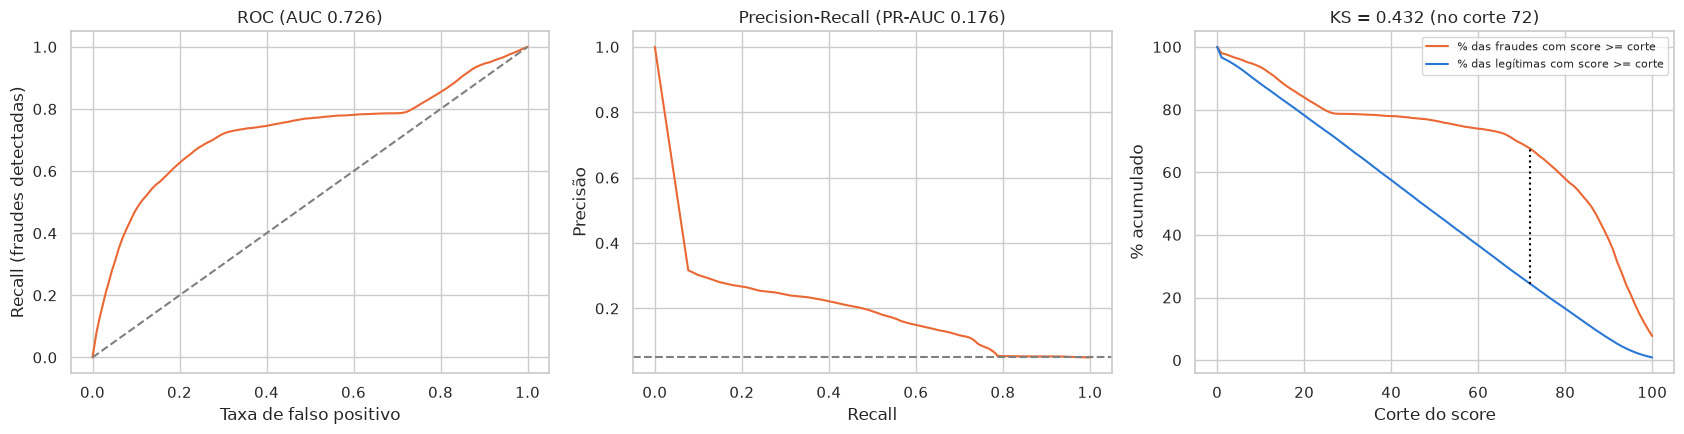

In [27]:
fpr, tpr, _ = roc_curve(df["fraude"], df["score"])
precisao, recall, _ = precision_recall_curve(df["fraude"], df["score"])

# KS: % de fraudes e de legítimas com score >= corte, para cada corte
cortes = np.arange(0, 101)
pct_fraude = [(df.loc[df["fraude"] == 1, "score"] >= c).mean() * 100 for c in cortes]
pct_legit = [(df.loc[df["fraude"] == 0, "score"] >= c).mean() * 100 for c in cortes]
gap = np.array(pct_fraude) - np.array(pct_legit)
corte_ks = cortes[gap.argmax()]

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(17, 4.5))

ax1.plot(fpr, tpr, color=FRAUD_COLOR)
ax1.plot([0, 1], [0, 1], color="gray", linestyle="--")
ax1.set(title=f"ROC (AUC {metricas_base['ROC-AUC']:.3f})", xlabel="Taxa de falso positivo", ylabel="Recall (fraudes detectadas)")

ax2.plot(recall, precisao, color=FRAUD_COLOR)
ax2.axhline(df["fraude"].mean(), color="gray", linestyle="--")  # modelo aleatório
ax2.set(title=f"Precision-Recall (PR-AUC {metricas_base['PR-AUC']:.3f})", xlabel="Recall", ylabel="Precisão")

ax3.plot(cortes, pct_fraude, color=FRAUD_COLOR, label="% das fraudes com score >= corte")
ax3.plot(cortes, pct_legit, color=LEGIT_COLOR, label="% das legítimas com score >= corte")
ax3.vlines(corte_ks, pct_legit[corte_ks], pct_fraude[corte_ks], color="black", linestyle=":")
ax3.set(title=f"KS = {gap.max() / 100:.3f} (no corte {corte_ks})", xlabel="Corte do score", ylabel="% acumulado")
ax3.legend(fontsize=8)

plt.tight_layout()
plt.show()

### Tabela de KS por decil

O score é dividido em 10 faixas com o mesmo número de transações, da de maior risco para a de menor. Para cada decil: taxa de fraude, % das fraudes capturadas até ali e o KS.

In [28]:
def ks_por_decil(data, col, maior_e_pior=False):
    data = data[[col, "fraude"]].dropna()
    tabela = data.groupby(pd.qcut(data[col], 10, duplicates="drop"), observed=True)["fraude"].agg(
        fraudes="sum", total="size")
    if maior_e_pior:  # para o score: começa pelos decis de maior risco
        tabela = tabela.iloc[::-1]

    tabela["nao_fraudes"] = tabela["total"] - tabela["fraudes"]
    tabela["taxa_fraude_%"] = tabela["fraudes"] / tabela["total"] * 100
    tabela["fraude_acum_%"] = tabela["fraudes"].cumsum() / tabela["fraudes"].sum() * 100
    tabela["nao_fraude_acum_%"] = tabela["nao_fraudes"].cumsum() / tabela["nao_fraudes"].sum() * 100
    tabela["ks"] = tabela["fraude_acum_%"] - tabela["nao_fraude_acum_%"]
    return tabela.round(1)

decis_score = ks_por_decil(df, "score", maior_e_pior=True)
decis_score

,fraudes,total,nao_fraudes,taxa_fraude_%,fraude_acum_%,nao_fraude_acum_%,ks
score,,,,,,,
"(88.0, 100.0]",3102,14228,11126,21.8,41.4,7.8,33.6
"(78.0, 88.0]",1340,15065,13725,8.9,59.2,17.4,41.8
"(68.0, 78.0]",793,14910,14117,5.3,69.8,27.3,42.5
"(58.0, 68.0]",321,15018,14697,2.1,74.1,37.7,36.4
"(48.0, 58.0]",195,14935,14740,1.3,76.7,48.0,28.7
"(38.0, 48.0]",95,15093,14998,0.6,77.9,58.5,19.4
"(28.0, 38.0]",50,14998,14948,0.3,78.6,69.0,9.6
"(18.0, 28.0]",458,14950,14492,3.1,84.7,79.2,5.5
"(8.0, 18.0]",707,14996,14289,4.7,94.1,89.2,4.9


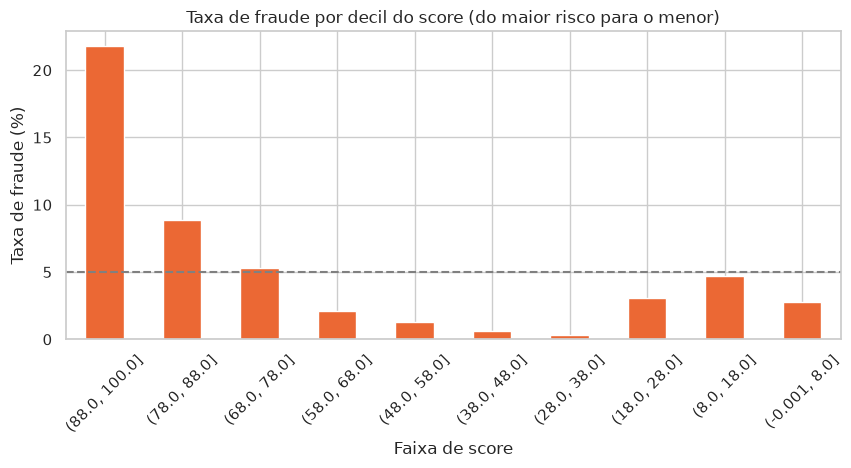

In [29]:
ax = decis_score["taxa_fraude_%"].plot(kind="bar", color=FRAUD_COLOR, figsize=(10, 4))
ax.axhline(df["fraude"].mean() * 100, color="gray", linestyle="--")  # média geral
ax.set(title="Taxa de fraude por decil do score (do maior risco para o menor)", xlabel="Faixa de score", ylabel="Taxa de fraude (%)")
plt.xticks(rotation=45)
plt.show()

**Leitura:**
- O decil de maior score (89–100) tem **21,8% de fraude** e sozinho captura **41,4% das fraudes**. Os três primeiros decis (score > 68) capturam ~70%: o score ordena bem o risco no topo.
- **O score não é monotônico:** os 3 decis de **menor** score (0–28) têm 2,8–4,7% de fraude, mais que os decis do meio (0,3–2,1%), e somam **~21% das fraudes**. Existe um grupo de fraudes que o champion classifica como muito seguras: um ponto cego que o Challenger pode tentar capturar. É esse grupo que deixa a curva ROC quase plana no meio.

### Lucro por ponto de corte

A função abaixo aplica a regra de negócio: recusa quando `score >= corte` e soma o resultado das transações aprovadas. Antes de usar, ela é conferida num exemplo calculado à mão.

In [30]:
def lucro(dados, corte, col_score="score"):
    aprovada = dados[col_score] < corte
    ganho = 0.10 * dados.loc[aprovada & (dados["fraude"] == 0), "monto"].sum()
    perda = dados.loc[aprovada & (dados["fraude"] == 1), "monto"].sum()
    return ganho - perda

# Conferência à mão: corte 50 aprova as linhas 1 e 3 → 0,10 × 100 − 30 = −20
exemplo = pd.DataFrame({"score": [20, 90, 40], "monto": [100.0, 50.0, 30.0], "fraude": [0, 1, 1]})
assert lucro(exemplo, 50) == -20
print("Exemplo:", lucro(exemplo, 50))

Exemplo: -20.0


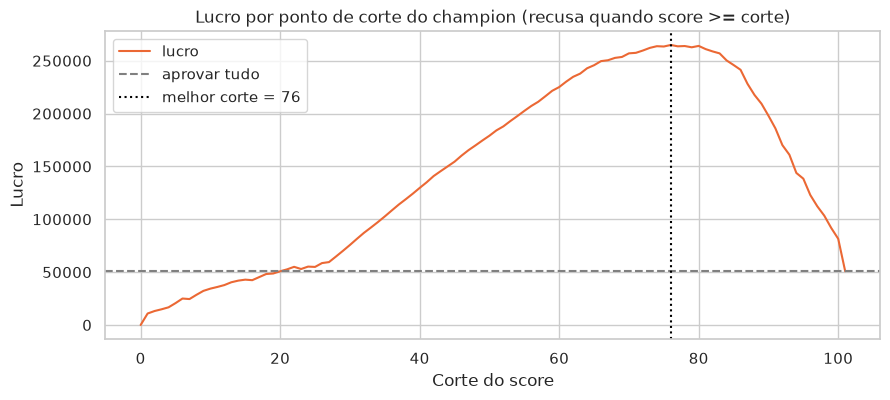

In [31]:
cortes = np.arange(0, 102)  # corte 101 = aprovar tudo (nenhum score chega a 101)
curva = pd.DataFrame({
    "corte": cortes,
    "lucro": [lucro(df, c) for c in cortes],
    "taxa_recusa_%": [(df["score"] >= c).mean() * 100 for c in cortes],
}).set_index("corte")

lucro_aprovar_tudo = lucro(df, 101)
melhor_corte = curva["lucro"].idxmax()

ax = curva["lucro"].plot(color=FRAUD_COLOR, figsize=(10, 4))
ax.axhline(lucro_aprovar_tudo, color="gray", linestyle="--", label="aprovar tudo")
ax.axvline(melhor_corte, color="black", linestyle=":", label=f"melhor corte = {melhor_corte}")
ax.set(title="Lucro por ponto de corte do champion (recusa quando score >= corte)", xlabel="Corte do score", ylabel="Lucro")
ax.legend()
plt.show()

In [32]:
def resumo_corte(dados, corte, col_score="score"):
    recusada = dados[col_score] >= corte
    fraude = dados["fraude"] == 1
    return pd.Series({
        "corte": corte,
        "lucro": lucro(dados, corte, col_score),
        "lucro_aprovar_tudo": lucro(dados, np.inf, col_score),
        "taxa_recusa_%": recusada.mean() * 100,
        "recall_%": (recusada & fraude).sum() / fraude.sum() * 100,      # fraudes recusadas / total de fraudes
        "precisao_%": (recusada & fraude).sum() / recusada.sum() * 100,  # fraudes entre as recusadas
    })

resumo_base = resumo_corte(df, melhor_corte)
resumo_base.round(2)

corte                     76.00
lucro                 264929.07
lucro_aprovar_tudo     50848.78
taxa_recusa_%             22.45
recall_%                  63.03
precisao_%                14.04
dtype: float64

### Conclusão do objetivo 1: performance do champion

| Métrica | Base completa |
|---|---|
| ROC-AUC | 0,726 |
| PR-AUC (aleatório = taxa de fraude) | 0,176 (0,050) |
| KS | 0,432 |
| Melhor corte (score >= 76 → recusa) | lucro de 264.929 |
| Lucro aprovando tudo | 50.849 |
| Taxa de recusa no corte | 22,4% |
| Recall / precisão no corte | 63,0% / 14,0% |

**Leitura**
- O champion **separa bem o topo do risco**: o decil de maior score captura 41% das fraudes, e o KS de 0,43 é bem maior que o de qualquer variável numérica sozinha (`f`, 0,28). Mas a `o` sozinha já chega a 0,45 (EDA).
- Ele tem um **ponto cego**: ~21% das fraudes estão nos 3 decis de menor score, como se fossem transações muito seguras.
- No melhor corte (recusar `score >= 76`), o lucro é **~5× o de aprovar tudo** (264,9 mil vs 50,8 mil), recusando 22% das transações e barrando 63% das fraudes.
- O corte de 76 é um diagnóstico na base completa. O corte usado na comparação com o novo modelo é escolhido só com os dados de validação (seção 6) e fica em 74, porque o score médio cai em abril (de ~50 no treino para ~45 na validação e no teste, ver seção 3).

**Por que essas métricas**
- **Acurácia não serve:** aprovar tudo já dá 95% de acurácia sem pegar nenhuma fraude.
- **PR-AUC em vez de só ROC-AUC:** com 5% de fraude, a ROC-AUC é inflada pelas muitas legítimas fáceis de separar. A PR-AUC mede o desempenho na classe de fraude, e a referência dela é 0,05, não 0,5.
- **KS:** é o padrão de mercado em crédito e fraude e é fácil de ler ("no melhor corte, separa 43 p.p. mais fraude que legítima").
- **O lucro decide:** as métricas acima medem separação; a decisão de negócio (onde cortar) é tomada pelo lucro, que pesa o valor de cada transação.

A comparação com o novo modelo, no mesmo período de teste, está na seção 7.

## Objetivo 2a: treino do novo modelo (challenger)

Esta parte constrói o modelo desafiante (Challenger). Ela começa pela base preparada com as decisões da EDA e segue os passos:
- split out-of-time em treino, validação e teste;
- features que dependem de outras linhas (calculadas só no treino);
- treino do LightGBM e da regressão logística (baseline);
- escolha do ponto de corte pelo lucro em validação;
- comparação com o champion no teste.

### Base preparada

Essa etapa consiste em realizar as transformações linha a linha antes de realizar o split dos dados para evitar qualquer leakage dentro das amostras resultantes. Para tanto, foram implementadas as seguintes transformações que foram trabalhadas no EDA:
- hora do dia;
- `pais` (BR, AR, UY, US e OUTROS);
- `o` com o nulo como categoria;
- drop de `k`, `c`, `e`, `g` e `i`.

In [33]:
INCIDENTE_BC_INICIO, INCIDENTE_BC_FIM = "2020-03-09", "2020-03-14"  # fim exclusivo: até 13/03 23:59
CATEGORICAS = ["a", "n", "o", "p", "pais"]
COLUNAS_DROP = ["k", "c", "e", "g", "i"]

def preparar_base(df):
    base = df.copy()
    base["fecha"] = pd.to_datetime(base["fecha"])

    # Hora do dia: risco maior na madrugada
    base["hora"] = base["fecha"].dt.hour

    # País: 4 principais + OUTROS (demais países e nulos)
    base["pais"] = base["g"].where(base["g"].isin(PAISES_PRINCIPAIS), "OUTROS")

    # o: nulo vira categoria (grupo de menor risco)
    base["o"] = base["o"].fillna("nulo")

    # Categóricas no formato que o LightGBM usa nativamente
    for col in CATEGORICAS:
        base[col] = base[col].astype(str).astype("category")

    return base.drop(columns=COLUNAS_DROP)

base = preparar_base(df_bruto)
base.shape

(150000, 17)

### Split out-of-time (treino, validação e teste)

O split baseado em data foi realizado considerando o comportamento do modelo de fraude em ambiente produtivo. Ao utilizar amostras out-of-time garantimos que o modelo tem as transações simuladas no tempo adequado. 

| Conjunto | Período | Uso |
|---|---|---|
| **treino** | 08/03 a 05/04 | ajustar o modelo e todas as transformações que dependem de outras linhas |
| **validação** | 06/04 a 12/04 | early stopping, comparação entre modelos e escolha do ponto de corte |
| **teste** | 13/04 a 21/04 | usado **uma única vez**, no fim, para a comparação com o champion |

Os cortes caem em domingos (05/04 e 12/04), então cada semana fica inteira em um único conjunto.

In [34]:
VALIDACAO_INICIO = "2020-04-06"
TESTE_INICIO = "2020-04-13"

df_treino = base[base["fecha"] < VALIDACAO_INICIO]
df_val = base[(base["fecha"] >= VALIDACAO_INICIO) & (base["fecha"] < TESTE_INICIO)]
df_teste = base[base["fecha"] >= TESTE_INICIO]

# Conferência: nenhuma transação perdida ou repetida
assert len(df_treino) + len(df_val) + len(df_teste) == len(base)

In [35]:
splits = {"treino": df_treino, "validação": df_val, "teste": df_teste}

resumo_split = pd.DataFrame({
    nome: {
        "início": dados["fecha"].min().date(),
        "fim": dados["fecha"].max().date(),
        "dias": dados["fecha"].dt.date.nunique(),
        "transações": len(dados),
        "% das transações": len(dados) / len(base) * 100,
        "fraudes": dados["fraude"].sum(),
        "taxa de fraude %": dados["fraude"].mean() * 100,
        "monto total": dados["monto"].sum(),
        "score médio (champion)": dados["score"].mean(),
    }
    for nome, dados in splits.items()
}).T

# As colunas numéricas ficam como texto por causa das datas: converte para poder arredondar
colunas_numericas = resumo_split.columns.drop(["início", "fim"])
resumo_split[colunas_numericas] = resumo_split[colunas_numericas].astype(float).round(2)
resumo_split

,início,fim,dias,transações,% das transações,fraudes,taxa de fraude %,monto total,score médio (champion)
treino,2020-03-08,2020-04-05,29.0,90063.0,60.04,4607.0,5.12,4055638.11,50.26
validação,2020-04-06,2020-04-12,7.0,24443.0,16.30,1322.0,5.41,977182.94,44.93
teste,2020-04-13,2020-04-21,9.0,35494.0,23.66,1571.0,4.43,1495649.07,44.66


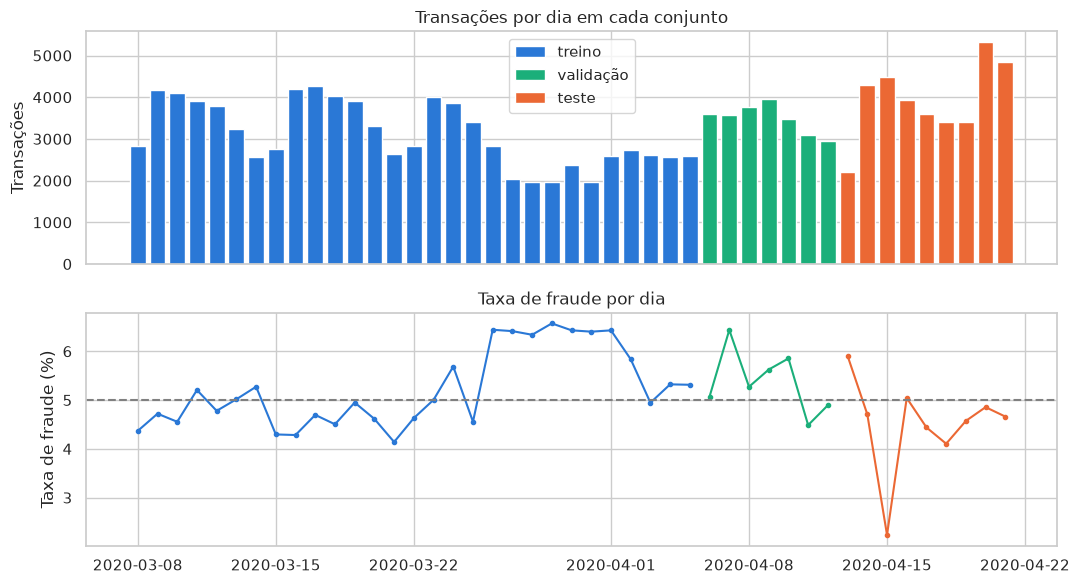

In [36]:
cores_split = {"treino": LEGIT_COLOR, "validação": "#1baf7a", "teste": FRAUD_COLOR}
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 6), sharex=True)

for nome, dados in splits.items():
    diario = dados.groupby(dados["fecha"].dt.floor("D"))["fraude"].agg(transacoes="size", taxa="mean")
    ax1.bar(diario.index, diario["transacoes"], color=cores_split[nome], label=nome)
    ax2.plot(diario.index, diario["taxa"] * 100, color=cores_split[nome], marker="o", markersize=3)

ax1.set(title="Transações por dia em cada conjunto", ylabel="Transações")
ax1.legend()
ax2.axhline(base["fraude"].mean() * 100, color="gray", linestyle="--")  # média geral
ax2.set(title="Taxa de fraude por dia", ylabel="Taxa de fraude (%)")
plt.tight_layout()
plt.show()

- **Tamanho:** O dataset de Treino fica com ~60% das transações (29 dias), validação com ~16% (7 dias) e teste com ~24% (9 dias). Essa divisão foi pensada de modo que todos tenham um número mínimo superior a 1.300 fraudes que é o suficiente para medir as métricas com estabilidade.
- **Taxa de fraude:** 5,1% em treino, 5,4% em validação e **4,4% em teste**. 
  - A queda na taxa de fraude em teste pode acontecer devido a maturidade da target de modo que as fraudes mais recentes podem ainda não ter sido contestadas no momento de extração dos dados.
- **Problema nas datas de `b`/`c`** (09 a 13/03): Apesar da grande taxa de nulos no período, a taxa de fraude que é apresentada é baixa se relativa a taxa de fraude total, dito isso manteve-se a `b`.

### Feature engineering (ajustado no treino)

Algumas features dependem de outras transações para serem calculadas e caso fossem calculadas na base inteira o modelo usaria a informação dos conjuntos de validação e de teste, e a avaliação de performance do modelo ficaria enviesada. Por isso elas são ajustadas com base no conjunto de dados de treinamento e depois aplicadas seguindo a formatação definida nos três conjuntos.

Um exemplo disso é a frequência da categoria `j`. `j` tem 8.324 categorias, então em vez de usá-la diretamente usamos quantas transações do treino pertencem àquela categoria.

In [37]:
# Frequência de cada categoria de j, contada só no treino
freq_j = df_treino["j"].value_counts()

def adicionar_features(dados):
    dados = dados.copy()
    # Categoria nunca vista no treino recebe frequência 0
    dados["j_freq"] = dados["j"].map(freq_j).fillna(0)
    return dados

df_treino = adicionar_features(df_treino)
df_val = adicionar_features(df_val)
df_teste = adicionar_features(df_teste)

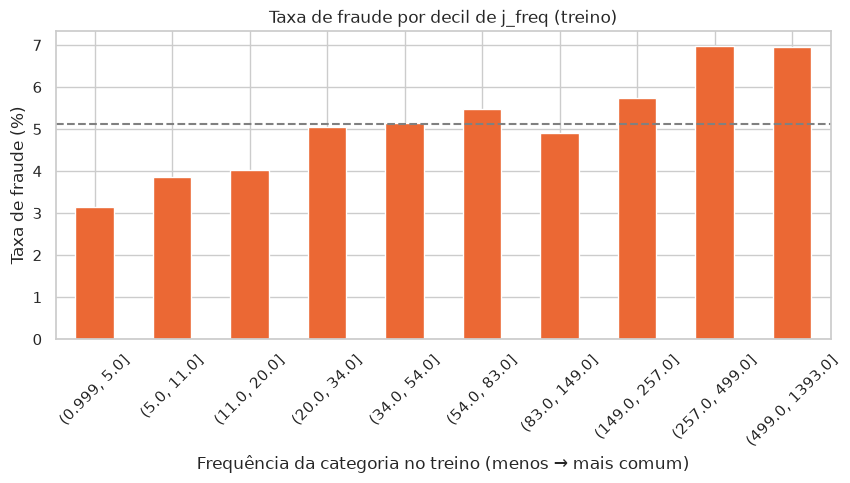

,KS de j_freq,% categoria nova (j_freq = 0),taxa de fraude nas categorias novas %
treino,0.100,0.000,NaN
validação,0.095,2.307,4.255
teste,0.094,2.474,3.986


In [38]:
# Taxa de fraude por decil de j_freq, no treino
taxa_decil = df_treino.groupby(pd.qcut(df_treino["j_freq"], 10, duplicates="drop"), observed=True)["fraude"].mean() * 100
ax = taxa_decil.plot(kind="bar", color=FRAUD_COLOR, figsize=(10, 4))
ax.axhline(df_treino["fraude"].mean() * 100, color="gray", linestyle="--")  # média do treino
ax.set(title="Taxa de fraude por decil de j_freq (treino)", xlabel="Frequência da categoria no treino (menos → mais comum)",
       ylabel="Taxa de fraude (%)")
plt.xticks(rotation=45)
plt.show()

# Estabilidade do sinal e categorias novas em cada conjunto
pd.DataFrame({
    nome: {
        "KS de j_freq": ks_2samp(dados.loc[dados["fraude"] == 1, "j_freq"], dados.loc[dados["fraude"] == 0, "j_freq"]).statistic,
        "% categoria nova (j_freq = 0)": (dados["j_freq"] == 0).mean() * 100,
        "taxa de fraude nas categorias novas %": dados.loc[dados["j_freq"] == 0, "fraude"].mean() * 100,
    }
    for nome, dados in {"treino": df_treino, "validação": df_val, "teste": df_teste}.items()
}).T.round(3)

- Olhamos que as categorias dos últimos dois decis (as mais frequentes) são as que apresentam mais fraude saindo de 3,1% nas categorias menos frequentes para 7,0% nas mais comuns.
- Só 2,3% a 2,5% das transações dos dados de validação e dos de teste têm uma categoria que não aparece no treino. Elas recebem frequência 0, e a taxa de fraude delas é normal (~4%), então esse tratamento não distorce o resultado da análise.

### Considerações
- Não usamos a descrição contida na coluna `i` pois seria algo que podemos usar técnicas de PLN ou até modelos fundacionais, mas foge do escopo desse projeto
- Também não foram criadas features de velocidade (atreladas a informações como ip, tempo decorrido entre transações do mesmo usuário e etc) visto que não tem-se um identificador comum das transações declarado nas colunas
- Foram feitos alguns testes de combinações de features como valor transacionado relativo ao país, valor / `f` e valor / `l`, porém nenhuma trouxe ganho acima do ruído. Os testes estão detalhados na seção abaixo

In [39]:
FEATURES = ["a", "b", "d", "f", "h", "l", "m", "n", "o", "p", "monto", "hora", "pais", "j_freq"]
ALVO = "fraude"

X_treino, y_treino = df_treino[FEATURES], df_treino[ALVO]
X_val, y_val = df_val[FEATURES], df_val[ALVO]
X_teste, y_teste = df_teste[FEATURES], df_teste[ALVO]

# Conferências
assert len(X_treino) + len(X_val) + len(X_teste) == len(base)
assert not pd.concat([X_treino, X_val, X_teste])[CATEGORICAS].isnull().any().any()

print("Formato:", {"treino": X_treino.shape, "validação": X_val.shape, "teste": X_teste.shape})

# Nulos que sobram: só nas numéricas, tratados nativamente pelo LightGBM
pd.DataFrame({"treino": X_treino.isnull().sum(), "validação": X_val.isnull().sum(), "teste": X_teste.isnull().sum()}).query(
    "treino > 0 or validação > 0 or teste > 0")

Formato: {'treino': (90063, 14), 'validação': (24443, 14), 'teste': (35494, 14)}


,treino,validação,teste
b,12453,200,331
d,270,62,33
f,8,3,0
l,8,3,0
m,270,62,33


#### Teste de combinações de features

Na análise exploratória a feature de `f` baixo e `monto` alto aparecem ligados a mais fraude independentemente. A hipótese é se a combinação dessas features (respectivamente seus comportamentos) resultaria em algum ganho para o modelo, ou se apenas a abstração interna do modelo já seria o suficiente para identificar tais padrões

Testamos três candidatas:
- `monto_rel_pais`: `monto` dividido pela média de `monto` do país no treino
- `monto_sobre_f` e `monto_sobre_l`: `monto` dividido por `f + 1` e por `l + 1`. 

In [40]:
# Candidatas, todas calculadas com informação do treino
media_monto_pais = df_treino.groupby("pais", observed=True)["monto"].mean()

def adicionar_combinacoes(dados):
    dados = dados.copy()
    dados["monto_rel_pais"] = dados["monto"] / dados["pais"].map(media_monto_pais).astype(float)
    dados["monto_sobre_f"] = dados["monto"] / (dados["f"].fillna(0) + 1)
    dados["monto_sobre_l"] = dados["monto"] / (dados["l"].fillna(0) + 1)
    return dados

CANDIDATAS = ["monto_rel_pais", "monto_sobre_f", "monto_sobre_l"]
treino_comb = adicionar_combinacoes(df_treino)
val_comb = adicionar_combinacoes(df_val)

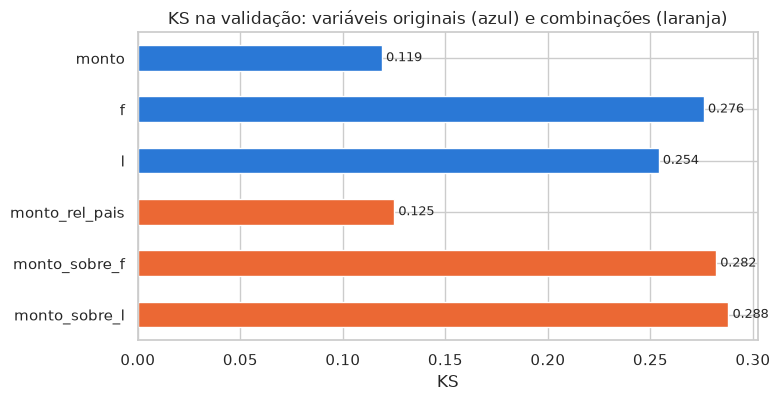

In [41]:
def ks(dados, col):
    x = dados[[col, "fraude"]].dropna()
    return ks_2samp(x.loc[x["fraude"] == 1, col], x.loc[x["fraude"] == 0, col]).statistic

# KS na validação: cada candidata ao lado das variáveis de origem
comparacao_ks = pd.Series({col: ks(val_comb, col) for col in ["monto", "f", "l"] + CANDIDATAS}).round(3)

cores = [FRAUD_COLOR if col in CANDIDATAS else LEGIT_COLOR for col in comparacao_ks.index]
ax = comparacao_ks.plot(kind="barh", color=cores, figsize=(8, 4))
ax.bar_label(ax.containers[0], fmt="%.3f", padding=3, fontsize=9)
ax.set(title="KS na validação: variáveis originais (azul) e combinações (laranja)", xlabel="KS")
ax.invert_yaxis()
plt.show()

Se olharmos ao gráfico vemos que o comparativo aponta um resultado interessante, as features combinadas não ganham praticamente nada em performance comparadas com as features em seu estado primordial. Logo, pode-se inferir que para as que foram selecionadas podemos seguir sem alteração. Isso pode ser um caso diferente para outras combinações de features e até criação de features de velocidade, porém como foi referido, está fora do escopo e do tempo hábil deste projeto.

### Features finais

| Feature | Tipo | Por que entra |
|---|---|---|
| `f`, `l`, `m` | numérica | Fraude nos menores valores |
| `d` | numérica | KS moderado de 0,17 |
| `h` | numérica | sinal fraco (KS 0,09), mas com tendência consistente |
| `b` | numérica | sinal concentrado nos maiores valores (~9% de fraude no último decil) |
| `monto` | numérica | fraude aparece concentrada nos valores altos |
| `o` | categórica | KS 0,45: `N` concentra metade das fraudes; nulo = grupo de menor risco |
| `n` | categórica | `n = 0` tem 16,1% de fraude |
| `p` | categórica | `p = N` tem 7,6% de fraude vs 2,9% em `Y` |
| `a` | categórica | níveis 1 a 3 com 7,8% a 9,4% de fraude vs 4,5% no nível 4 |
| `pais` | categórica | BR 5,5%, AR 3,7%, UY 1,0%, US 3,1% |
| `hora` | numérica | madrugada (0h a 5h) com **11,3%** de fraude |
| `j_freq` | numérica | categorias mais comuns têm mais fraude (KS 0,10, estável) |

Total de 14 features

### Treino dos modelos

Foram treinados dois modelos com as 14 features resultantes da análise do EDA + Feature engineering:
- uma **regressão logística**, modelo mais simples e com menor complexidade que serve de baseline.
- o **LightGBM**, que é o Challenger escolhido para comparar com o modelo vigente/champion (scores da tabela).

Os dois aprendem só com o dataset de treino. O conjunto de validação é usado para o early stopping do LightGBM e para comparar os modelos entre si e com o champion.

#### Baseline: regressão logística

A regressão logística não aceita nulos nem categorias em texto, então ela recebe um pré-processamento próprio ajustado no momento treino:
- Para as variáveis numéricas é feito o preenchimento dos nulos com um imputer com a mediana do treino e adicionou-se uma coluna de flag mostrando onde havia o nulo para não perder seu sinal
- As variáveis numéricas são padronizadas usando um StandardScaler jogando a média para 0 e std para 1
- Para as features categóricas é usado o one-hot encoding 

In [42]:
from sklearn.pipeline import make_pipeline
from sklearn.compose import make_column_transformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression

NUMERICAS = [c for c in FEATURES if c not in CATEGORICAS]

pre_processamento = make_column_transformer(
    (make_pipeline(SimpleImputer(strategy="median", add_indicator=True), StandardScaler()), NUMERICAS),
    (OneHotEncoder(handle_unknown="ignore"), CATEGORICAS),
)
modelo_lr = make_pipeline(pre_processamento, LogisticRegression(max_iter=2000))
modelo_lr.fit(X_treino, y_treino)

prob_val_lr = modelo_lr.predict_proba(X_val)[:, 1]

#### Challenger: LightGBM

O LightGBM usa as features sem qualquer transformação, sendo que internamente é feito o tratamento das categóricas como tipo `category`, as numéricas como tipo `numeric` e os nulos são tratados pela própria lógica interna do modelo.

A princípio não foi feita uma busca de hiperparâmetros, assim atendo-se ao padrão, com uma taxa de aprendizado de 0,05 e early stopping em que o modelo avalia a cada iteração se houve melhora nos resultados sobre o conjunto de validação, e caso não, ele para depois de 100 árvores sem ganho.

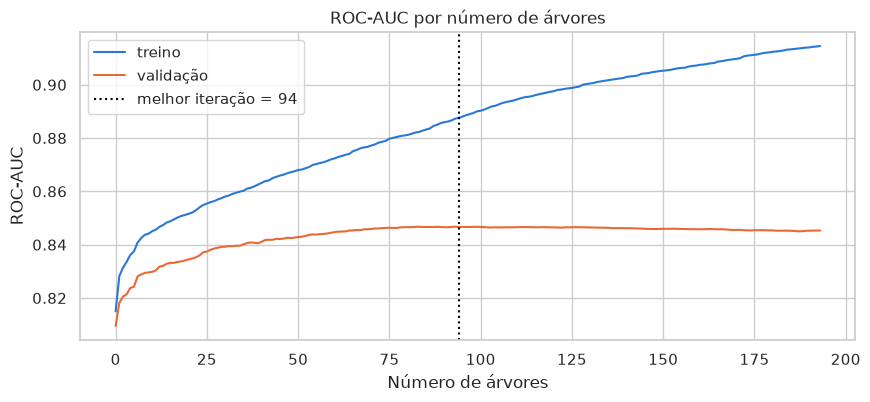

In [43]:
import lightgbm as lgb

modelo_lgbm = lgb.LGBMClassifier(n_estimators=2000, learning_rate=0.05, random_state=42, verbose=-1)
modelo_lgbm.fit(
    X_treino, y_treino,
    eval_set=[(X_treino, y_treino), (X_val, y_val)],
    eval_names=["treino", "validação"],
    eval_metric="auc",
    callbacks=[lgb.early_stopping(100, verbose=False)],
)
prob_val_lgbm = modelo_lgbm.predict_proba(X_val)[:, 1]

auc = pd.DataFrame({nome: res["auc"] for nome, res in modelo_lgbm.evals_result_.items()})
ax = auc.plot(color=[LEGIT_COLOR, FRAUD_COLOR], figsize=(10, 4))
ax.axvline(modelo_lgbm.best_iteration_, color="black", linestyle=":", label=f"melhor iteração = {modelo_lgbm.best_iteration_}")
ax.set(title="ROC-AUC por número de árvores", xlabel="Número de árvores", ylabel="ROC-AUC")
ax.legend()
plt.show()

#### Comparação na validação

In [44]:
comparacao_val = pd.DataFrame({
    "champion (score)": metricas(y_val, df_val["score"]),
    "Regressão logística": metricas(y_val, prob_val_lr),
    "LightGBM": metricas(y_val, prob_val_lgbm),
}).T
comparacao_val.round(3)

,ROC-AUC,PR-AUC,KS
champion (score),0.725,0.247,0.445
Regressão logística,0.833,0.304,0.522
LightGBM,0.847,0.383,0.541


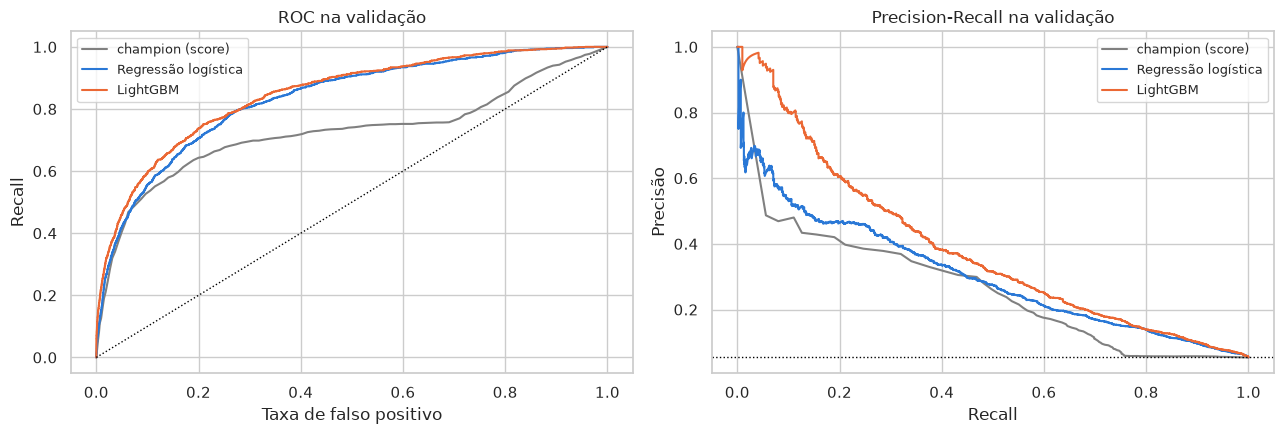

In [45]:
modelos_val = {"champion (score)": (df_val["score"], "gray"), "Regressão logística": (prob_val_lr, LEGIT_COLOR),
               "LightGBM": (prob_val_lgbm, FRAUD_COLOR)}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))
for nome, (prob, cor) in modelos_val.items():
    fpr, tpr, _ = roc_curve(y_val, prob)
    precisao, recall, _ = precision_recall_curve(y_val, prob)
    ax1.plot(fpr, tpr, color=cor, label=nome)
    ax2.plot(recall, precisao, color=cor, label=nome)

ax1.plot([0, 1], [0, 1], color="black", linestyle=":", linewidth=1)
ax1.set(title="ROC na validação", xlabel="Taxa de falso positivo", ylabel="Recall")
ax2.axhline(y_val.mean(), color="black", linestyle=":", linewidth=1)  # modelo aleatório
ax2.set(title="Precision-Recall na validação", xlabel="Recall", ylabel="Precisão")
ax1.legend(fontsize=9)
ax2.legend(fontsize=9)
plt.tight_layout()
plt.show()

Ambos os novos modelos superam o champion em validação em todas as métricas. O LightGBM fica à frente da regressão logística, mas a distância muda conforme a métrica: na ROC-AUC e no KS a diferença é pequena (cerca de 0,01 a 0,02), enquanto na PR-AUC ela é bem maior (0,38 contra 0,30). A PR-AUC olha só para a classe de fraude, e é nela que o LightGBM se destaca: ele acerta mais quando aponta uma transação como fraude, principalmente no topo do ranking. É lá que fica o ponto de corte.

A curva ROC mostra outra diferença. O champion tem um trecho quase plano no meio, com fraudes que ele classifica com score baixo. Os modelos novos não têm esse trecho: eles conseguem ordenar parte dessas fraudes.

A regressão logística ter ido tão bem também diz algo: boa parte do sinal está em poucas variáveis fortes, com destaque para `o`. Mesmo assim, o LightGBM entrega mais precisão sem nenhum trabalho extra de feature engineering, e por isso segue como Challenger.

Esses números são da aplicação dos modelos no conjunto de validação, que também foi usado no early stopping, então tendem a ser um pouco otimistas. A comparação final é realizada observando o conjunto de teste.

#### Importância das features

O cálculo de importância das features mede o impacto de cada feature na redução do erro do modelo

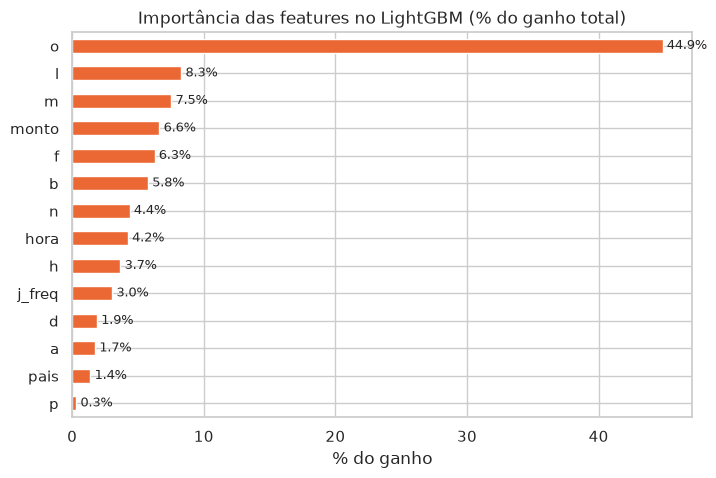

In [46]:
feat_importance = pd.Series(modelo_lgbm.booster_.feature_importance(importance_type="gain"), index=FEATURES)
feat_importance = (feat_importance / feat_importance.sum() * 100).sort_values()

ax = feat_importance.plot(kind="barh", color=FRAUD_COLOR, figsize=(8, 5))
ax.bar_label(ax.containers[0], fmt="%.1f%%", padding=3, fontsize=9)
ax.set(title="Importância das features no LightGBM (% do ganho total)", xlabel="% do ganho")
plt.show()

**Leitura**

O modelo confirma a leitura da EDA. `o` responde por quase metade do ganho, o que bate com o KS de 0,45 que ela tem sozinha. Depois vêm `l`, `m`, `f` e `monto`, as numéricas que já tinham a melhor separação.

A feature `p` possui uma relevância contrária à análise do EDA, ficando em última posição como mais baixa importância. Provavelmente porque a informação dela se sobrepõe à de `o` e `n`.

#### Teste: o modelo sem `o`

Pelo EDA foi-se levantado o teste sem o uso da feature `o` a fim de verificar seu peso no modelo. Para isso foi treinado o mesmo modelo (LightGBM) e avaliado o resultado

In [47]:
features_sem_o = [c for c in FEATURES if c != "o"]

modelo_sem_o = lgb.LGBMClassifier(n_estimators=2000, learning_rate=0.05, random_state=42, verbose=-1)
modelo_sem_o.fit(X_treino[features_sem_o], y_treino, eval_set=[(X_val[features_sem_o], y_val)], eval_metric="auc",
                 callbacks=[lgb.early_stopping(100, verbose=False)])

pd.DataFrame({
    "LightGBM com o": metricas(y_val, prob_val_lgbm),
    "LightGBM sem o": metricas(y_val, modelo_sem_o.predict_proba(X_val[features_sem_o])[:, 1]),
    "champion (score)": metricas(y_val, df_val["score"]),
}).T.round(3)

,ROC-AUC,PR-AUC,KS
LightGBM com o,0.847,0.383,0.541
LightGBM sem o,0.766,0.271,0.395
champion (score),0.725,0.247,0.445


Sem a presença da feature `o`, o modelo perde boa parte do desempenho, sua ROC-AUC cai de 0,85 para 0,77 e o KS de 0,54 para 0,40, abaixo do próprio champion (0,45). Dito isso, a decisão de manter `o`, mesmo com a altíssima taxa de nulos de 72,6% é resguardada pelo fato de exercer um dos maiores pesos em que seus nulos não são ruído para o modelo, mas sim informação discriminatória.

## Objetivo 2c: ponto de corte que maximiza o lucro

A regra de negócio consiste em que uma transação legítima aprovada rende 10% do valor total (`monto`), uma fraude aprovada custa 100% desse valor e uma transação recusada não rende nem custa nada. O modelo recusa quando a probabilidade de fraude é maior ou igual ao valor de corte. Esse valor de corte é escolhido com os resultados da **validação** do modelo, testando todos os valores e ficando com o que dá o maior retorno financeiro, sendo armazenado e aplicado no teste

De uma forma prática, para uma transação com probabilidade de fraude `p`, aprovar vale a pena quando o ganho esperado supera a perda esperada:

`(1 − p) · 0,10 · monto > p · monto`  →  `p < 0,10 / 1,10 = 1/11 ≈ 0,091`

O `monto` aparece dos dois lados e se cancela: o corte ideal não depende do valor da transação. Se as probabilidades do modelo forem bem calibradas, o melhor corte encontrado nos dados deve ficar perto de 0,091.

In [48]:
df_val = df_val.assign(prob_lgbm=prob_val_lgbm)

CORTES_PROB = np.round(np.arange(0, 1.0001, 0.005), 3)  # probabilidade do LightGBM
CORTES_SCORE = np.arange(0, 102)                        # score do champion (101 = aprovar tudo)

curva_lgbm = pd.Series({c: lucro(df_val, c, "prob_lgbm") for c in CORTES_PROB})
curva_champion = pd.Series({c: lucro(df_val, c, "score") for c in CORTES_SCORE})

# Pontos de corte congelados: não mudam mais daqui em diante
CORTE_LGBM = curva_lgbm.idxmax()
CORTE_CHAMPION = curva_champion.idxmax()
CORTE_TEORICO = 1 / 11
lucro_aprovar_tudo_val = lucro(df_val, np.inf, "score")

print(f"LightGBM: recusar quando prob >= {CORTE_LGBM} | champion: recusar quando score >= {CORTE_CHAMPION}")

LightGBM: recusar quando prob >= 0.075 | champion: recusar quando score >= 74


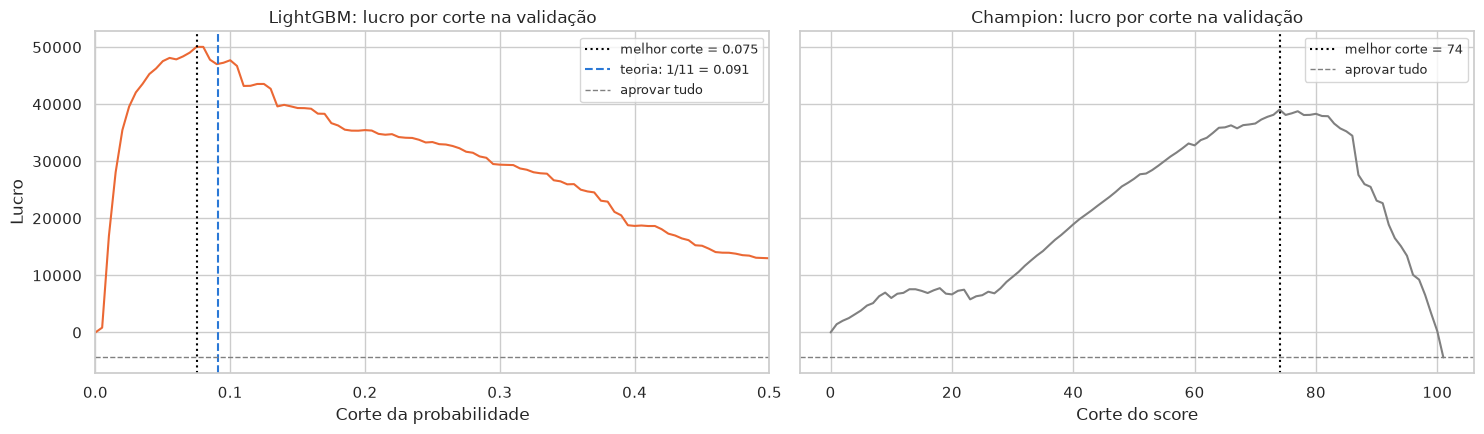

,corte,lucro,lucro_aprovar_tudo,taxa_recusa_%,recall_%,precisao_%
champion (score),74.000,39046.980,-4385.433,19.376,61.271,17.103
LightGBM,0.075,50043.586,-4385.433,16.913,65.809,21.045
LightGBM no corte teórico (1/11),0.091,47090.242,-4385.433,13.415,60.741,24.489


In [49]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 4.5), sharey=True)

ax1.plot(curva_lgbm.index, curva_lgbm.values, color=FRAUD_COLOR)
ax1.axvline(CORTE_LGBM, color="black", linestyle=":", label=f"melhor corte = {CORTE_LGBM}")
ax1.axvline(CORTE_TEORICO, color=LEGIT_COLOR, linestyle="--", label=f"teoria: 1/11 = {CORTE_TEORICO:.3f}")
ax1.set(title="LightGBM: lucro por corte na validação", xlabel="Corte da probabilidade", ylabel="Lucro", xlim=(0, 0.5))

ax2.plot(curva_champion.index, curva_champion.values, color="gray")
ax2.axvline(CORTE_CHAMPION, color="black", linestyle=":", label=f"melhor corte = {CORTE_CHAMPION}")
ax2.set(title="Champion: lucro por corte na validação", xlabel="Corte do score")

for ax in (ax1, ax2):
    ax.axhline(lucro_aprovar_tudo_val, color="gray", linestyle="--", linewidth=1, label="aprovar tudo")
    ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

pd.DataFrame({
    "champion (score)": resumo_corte(df_val, CORTE_CHAMPION, "score"),
    "LightGBM": resumo_corte(df_val, CORTE_LGBM, "prob_lgbm"),
    "LightGBM no corte teórico (1/11)": resumo_corte(df_val, CORTE_TEORICO, "prob_lgbm"),
}).T.round(3)

**Leitura**

O melhor corte do LightGBM no conjunto de validação é **0,075**, ao lado do valor teórico de 0,091. A curva é quase plana entre 0,05 e 0,10, então pequenas mudanças no corte não alteram muito o resultado. Isso é bom para produção, porque o resultado não depende de acertar o corte com precisão.

No melhor corte, o LightGBM gera 50,0 mil de lucro em validação, contra 39,0 mil do champion no melhor corte dele (score ≥ 74). Ele faz isso **recusando menos** (16,9% contra 19,4% das transações) e barrando mais fraude (recall de 65,8% contra 61,3%). A precisão também é maior: 21% das transações recusadas pelo LightGBM são fraude, contra 17% no champion.

### Por que o corte ficou perto de 1/11: calibração

O corte teórico só vale se a probabilidade do modelo for uma probabilidade de verdade: entre as transações com probabilidade de 8%, cerca de 8% devem ser fraude. O gráfico abaixo divide os conjuntos de validação e de teste em 10 faixas de probabilidade cada e compara a média prevista com a taxa de fraude real de cada faixa.

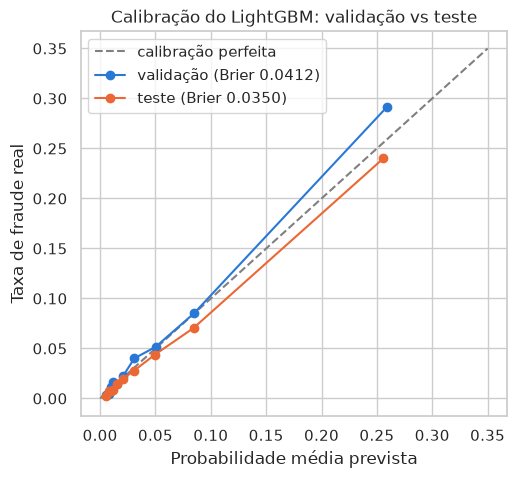

Validação: probabilidade média prevista 4.96% | taxa real 5.41%
Teste: probabilidade média prevista 4.92% | taxa real 4.43%


In [50]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

# O corte já está congelado acima; o teste entra aqui só para comparar a calibração
prob_teste_lgbm = modelo_lgbm.predict_proba(X_teste)[:, 1]

ax = plt.figure(figsize=(5.5, 5)).gca()
ax.plot([0, 0.35], [0, 0.35], color="gray", linestyle="--", label="calibração perfeita")
for nome, y, prob, cor in [("validação", y_val, prob_val_lgbm, LEGIT_COLOR), ("teste", y_teste, prob_teste_lgbm, FRAUD_COLOR)]:
    real, previsto = calibration_curve(y, prob, n_bins=10, strategy="quantile")
    ax.plot(previsto, real, marker="o", color=cor, label=f"{nome} (Brier {brier_score_loss(y, prob):.4f})")
ax.set(title="Calibração do LightGBM: validação vs teste", xlabel="Probabilidade média prevista", ylabel="Taxa de fraude real")
ax.legend()
plt.show()

print(f"Validação: probabilidade média prevista {prob_val_lgbm.mean():.2%} | taxa real {y_val.mean():.2%}")
print(f"Teste: probabilidade média prevista {prob_teste_lgbm.mean():.2%} | taxa real {y_teste.mean():.2%}")

Os pontos ficam colados na diagonal até perto de 0,10, que é a região onde o corte é decidido. Só no decil mais alto o modelo subestima um pouco (prevê 26% e acontece 29%), o que não afeta o corte. A média prevista (4,96%) também fica perto da taxa real (5,41%).

O LightGBM foi treinado sem reamostragem nem pesos de classe, e por isso as probabilidades já saem calibradas. Esse é um dos motivos de não termos usado SMOTE: ele distorceria as probabilidades, e o corte de 1/11 deixaria de valer.

No teste, o modelo superestima um pouco as probabilidades: a média prevista é 4,92% e a taxa real é 4,43%. A curva do teste fica abaixo da diagonal, principalmente no decil mais alto. Isso é coerente com a taxa de fraude mais baixa do teste, vista no split, e com a hipótese de maturidade do rótulo: parte das fraudes recentes pode ainda não ter sido confirmada. Mesmo assim, o desvio é pequeno e fica longe da região do corte.

## Objetivo 2b: comparação com o modelo atual no teste

O teste (13/04 a 21/04) não foi usado em nenhuma decisão prévia, sendo considerado apenas para avaliação final de performance. Ambos os modelos treinados usam as janelas de tempo da etapa anterior.

Além do champion e do LightGBM, a comparação de lucro inclui duas referências:
- **aprovar tudo**, que é o resultado sem nenhum modelo;
- **modelo perfeito**, que recusa todas as fraudes e aprova todas as legítimas. É o teto do lucro possível nesse período.

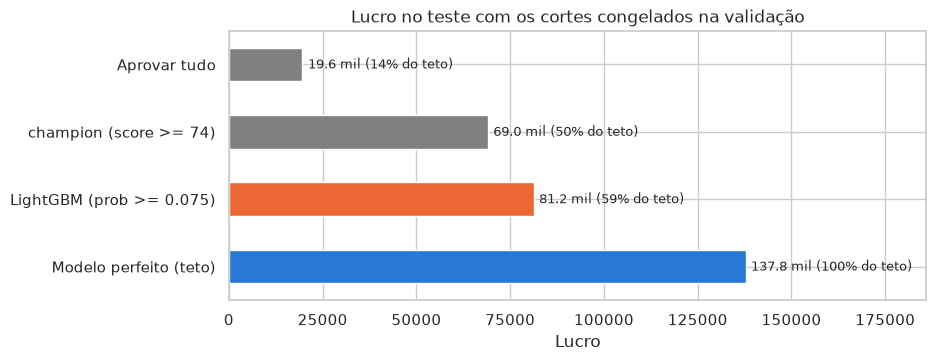

In [51]:
df_teste = df_teste.assign(prob_lgbm=modelo_lgbm.predict_proba(X_teste)[:, 1])

teto_teste = 0.10 * df_teste.loc[df_teste["fraude"] == 0, "monto"].sum()  # recusa todas as fraudes e aprova todas as legítimas
lucros_test = pd.Series({
    "Aprovar tudo": lucro(df_teste, np.inf, "score"),
    f"champion (score >= {CORTE_CHAMPION})": lucro(df_teste, CORTE_CHAMPION, "score"),
    f"LightGBM (prob >= {CORTE_LGBM})": lucro(df_teste, CORTE_LGBM, "prob_lgbm"),
    "Modelo perfeito (teto)": teto_teste,
})

ax = lucros_test.plot(kind="barh", color=["gray", "gray", FRAUD_COLOR, LEGIT_COLOR], figsize=(9, 3.5))
ax.bar_label(ax.containers[0], labels=[f"{v / 1000:.1f} mil ({v / teto_teste:.0%} do teto)" for v in lucros_test], padding=4, fontsize=9)
ax.set(title="Lucro no teste com os cortes congelados na validação", xlabel="Lucro", xlim=(0, teto_teste * 1.35))
ax.invert_yaxis()
plt.show()

No teste, o LightGBM gera **81,2 mil** de lucro, contra **69,0 mil** do champion: um ganho de 12,2 mil (+18%). Em relação ao teto, o LightGBM captura 59% do lucro possível e o champion, 50%. Aprovar tudo ficaria em 19,6 mil (14% do teto).

In [52]:
prob_test_lr = modelo_lr.predict_proba(X_teste)[:, 1]

ranking_test = pd.DataFrame({
    "champion (score)": metricas(y_teste, df_teste["score"]),
    "Regressão logística": metricas(y_teste, prob_test_lr),
    "LightGBM": metricas(y_teste, df_teste["prob_lgbm"])
}).T
decisao_test = pd.DataFrame({
    "champion (score)": resumo_corte(df_teste, CORTE_CHAMPION, "score"),
    "LightGBM": resumo_corte(df_teste, CORTE_LGBM, "prob_lgbm"),
}).T.drop(columns="corte")

# Métricas de decisão só para os dois modelos que tiveram corte escolhido na validação
ranking_test.join(decisao_test).round(3)

,ROC-AUC,PR-AUC,KS,lucro,lucro_aprovar_tudo,taxa_recusa_%,recall_%,precisao_%
champion (score),0.733,0.229,0.463,69022.810,19626.032,18.798,62.635,14.748
Regressão logística,0.832,0.272,0.512,NaN,NaN,NaN,NaN,NaN
LightGBM,0.845,0.339,0.534,81237.201,19626.032,16.701,65.882,17.460


O LightGBM supera o champion em todas as métricas do teste:
- na separação, a ROC-AUC sobe de 0,733 para 0,845, a PR-AUC de 0,229 para 0,339 e o KS de 0,463 para 0,534;
- na decisão, ele recusa menos transações (16,7% contra 18,8%), barra um pouco mais de fraude (recall de 65,9% contra 62,6%) e erra menos ao recusar (precisão de 17,5% contra 14,7%). Na prática, menos clientes legítimos são barrados para o mesmo nível de proteção.

### O ganho se repete dia a dia?

Um ganho no total do teste pode vir de um ou dois dias bons. Para checar se ele é consistente, calculamos o lucro dos dois modelos em cada dia do teste, com os mesmos cortes congelados, e comparamos.

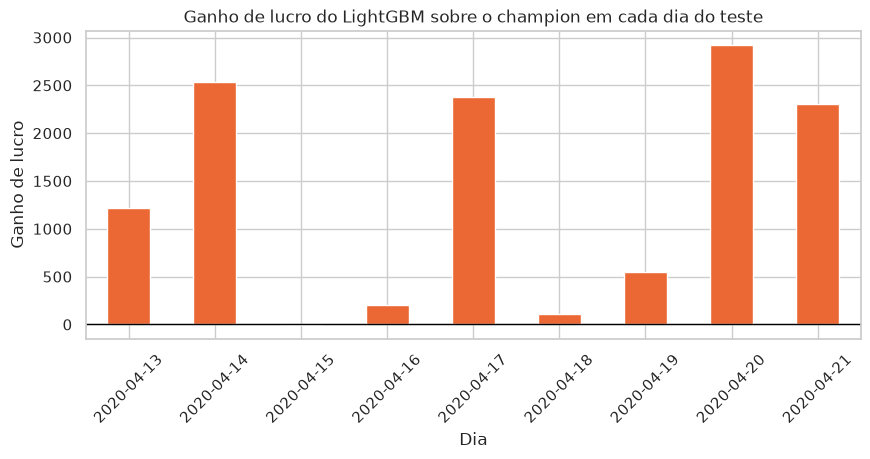

O LightGBM teve lucro maior em 8 de 9 dias


,LightGBM,champion,ganho do LightGBM
fecha,,,
2020-04-13,4446.0,3231.0,1215.0
2020-04-14,9966.0,7430.0,2536.0
2020-04-15,12142.0,12146.0,-4.0
2020-04-16,8287.0,8082.0,205.0
2020-04-17,9304.0,6924.0,2381.0
2020-04-18,7350.0,7244.0,106.0
2020-04-19,7857.0,7305.0,551.0
2020-04-20,9592.0,6668.0,2924.0
2020-04-21,12294.0,9993.0,2301.0


In [53]:
lucro_dia = pd.DataFrame({
    "LightGBM": df_teste.groupby(df_teste["fecha"].dt.date).apply(lambda d: lucro(d, CORTE_LGBM, "prob_lgbm")),
    "champion": df_teste.groupby(df_teste["fecha"].dt.date).apply(lambda d: lucro(d, CORTE_CHAMPION, "score")),
})
lucro_dia["ganho do LightGBM"] = lucro_dia["LightGBM"] - lucro_dia["champion"]

ax = lucro_dia["ganho do LightGBM"].plot(kind="bar", color=[FRAUD_COLOR if g > 0 else "gray" for g in lucro_dia["ganho do LightGBM"]],
                                          figsize=(10, 4))
ax.axhline(0, color="black", linewidth=1)
ax.set(title="Ganho de lucro do LightGBM sobre o champion em cada dia do teste", xlabel="Dia", ylabel="Ganho de lucro")
plt.xticks(rotation=45)
plt.show()

print(f"O LightGBM teve lucro maior em {(lucro_dia['ganho do LightGBM'] > 0).sum()} de {len(lucro_dia)} dias")
lucro_dia.round(0)

O LightGBM teve lucro maior em **8 dos 9 dias** do teste. No único dia restante (15/04) os dois ficam praticamente empatados, com diferença de 4. Os ganhos diários vão de cerca de 100 a 2,9 mil, e somados dão os 12,2 mil do total.

Ou seja, o ganho não vem de um dia atípico: ele aparece de forma repetida ao longo do período. Essa checagem é mais simples que um teste estatístico formal, mas responde à mesma pergunta prática: se o modelo novo for colocado em produção, ele tende a render mais na maioria dos dias.

## Conclusão
No conjunto de teste o LightGBM supera o champion em todas as métricas: ROC-AUC de 0,845 contra 0,733, PR-AUC de 0,339 contra 0,229 e KS de 0,534 contra 0,463. Observando a questão de lucratividade, o novo modelo gera 81,2 mil de lucro contra 69,0 mil, sendo esse um ganho de 12,2 mil no total, que se repetiu em 8 dos 9 dias do teste. Além disso, o LightGBM faz isso recusando menos transações (16,7% contra 18,8%), ou seja, com menos atrito para clientes com bom relacionamento (pagantes).

Ponto de corte que maximiza o lucro: Estabelece a recusa de uma transação quando a probabilidade resultante do modelo for maior ou igual a 0,075. Caso a taxa de fraude real em ambiente produtivo for menor ou maior que os 5% observados na amostra, o corte deve ser reajustado de acordo.

## Limitações e próximos passos

**Limitações**
- A amostra tem exatamente 5% de fraude e parece estratificada, então o lucro absoluto e o ponto de corte valem para essa taxa, não necessariamente para a de produção.
- Os dados cobrem só 6,5 semanas, no início da pandemia de COVID, um período de comportamento atípico.
- Não há identificador de usuário, cartão ou dispositivo, o que impede features de histórico por cliente, normalmente as mais fortes em fraude.
- As fraudes mais recentes podem não estar confirmadas (maturidade do rótulo), o que pode explicar a taxa de fraude menor no teste.
- O conjunto de validação foi usado para o early stopping, para comparar modelos e para escolher o corte. O teste ficou de fora dessas decisões, mas os números da validação tendem a ser otimistas.

**Próximos passos**
- Criar features de velocidade e de histórico por cliente, a partir de um identificador de usuário ou dispositivo.
- Fazer uma busca de hiperparâmetros no LightGBM.
- Recalibrar o ponto de corte com a taxa de fraude real de produção.
- Medir a incerteza do ganho com bootstrap, além da checagem dia a dia.
- Monitorar a taxa de nulos das variáveis (como no incidente de `b` e `c`) e a distribuição do score.
- Rodar o modelo em paralelo ao atual (shadow mode) antes de trocar a decisão em produção.

## Uso de IA

A IA foi usada como apoio ao longo do trabalho:
- no planejamento, para organizar as etapas e o cronograma;
- no código de análise, gráficos e modelos, a partir das minhas instruções;
- no rascunho e na revisão dos textos de leitura e conclusão;
- na revisão crítica de decisões, como o tratamento de nulos, o risco de vazamento, o uso do score como feature e a forma de medir a consistência do ganho.

Como verifiquei o que foi gerado:
- reexecutei o notebook do início ao fim e conferi se os números dos textos batem com as saídas;
- questionei as sugestões e mudei decisões por conta própria, como remover a flag de nulo de `b`, descartar o XGBoost, trocar o bootstrap pela checagem dia a dia e agrupar os países;
- pedi versões mais simples do código para conseguir explicar cada linha;
- reescrevi os textos com as minhas palavras.